Device: cpu

=== Detailed run (seed=42, epochs=8000) ===
Epoch      0 | total 5.699e-01 | pde 1.187e-02 | ic 5.500e-01 | bc 8.036e-03 | lr 1.0e-03
Epoch   1000 | total 4.482e-04 | pde 1.737e-04 | ic 1.026e-04 | bc 1.718e-04 | lr 1.0e-03
Epoch   2000 | total 5.492e-04 | pde 1.302e-04 | ic 1.514e-04 | bc 2.676e-04 | lr 5.0e-04
Epoch   3000 | total 1.327e-04 | pde 8.586e-05 | ic 9.353e-06 | bc 3.751e-05 | lr 5.0e-04
Epoch   4000 | total 1.497e-04 | pde 6.746e-05 | ic 1.371e-05 | bc 6.857e-05 | lr 2.5e-04
Epoch   5000 | total 7.223e-05 | pde 4.535e-05 | ic 7.017e-06 | bc 1.986e-05 | lr 2.5e-04
Epoch   6000 | total 5.536e-05 | pde 3.547e-05 | ic 2.654e-06 | bc 1.724e-05 | lr 1.3e-04
Epoch   7000 | total 4.210e-05 | pde 3.037e-05 | ic 1.698e-06 | bc 1.003e-05 | lr 1.3e-04

Trainable parameters:       3297
Model memory (KB):          12.87890625
Peak training memory (MB):  62.11372089385986
Training time (s):          97.19966435432434
Relative L2 error:          0.0021427072278635832
PDE res

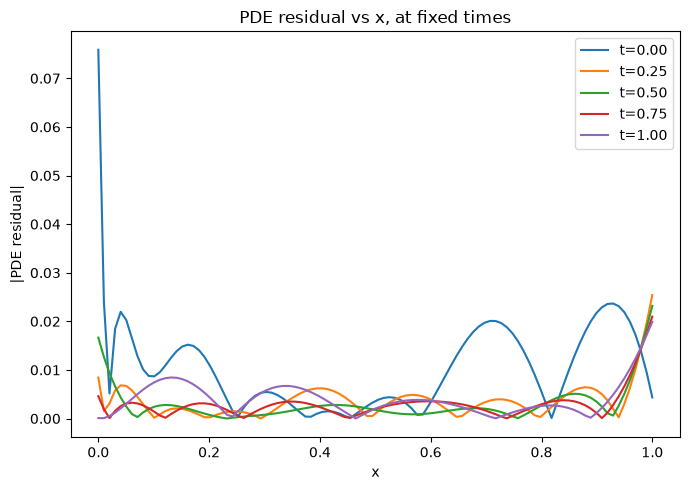

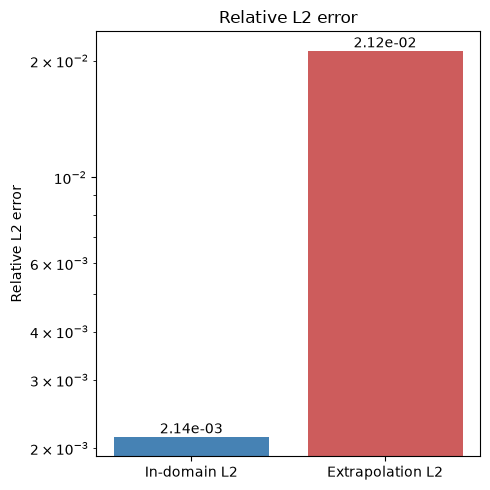

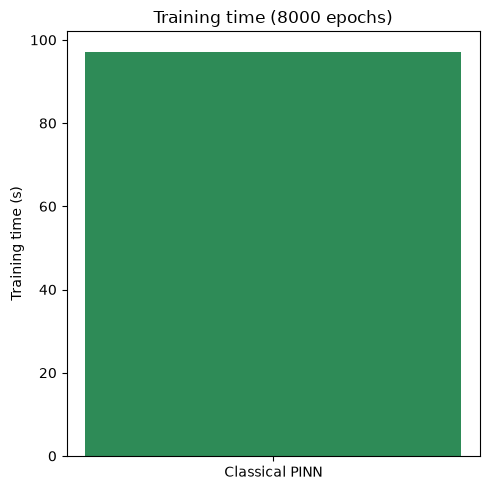

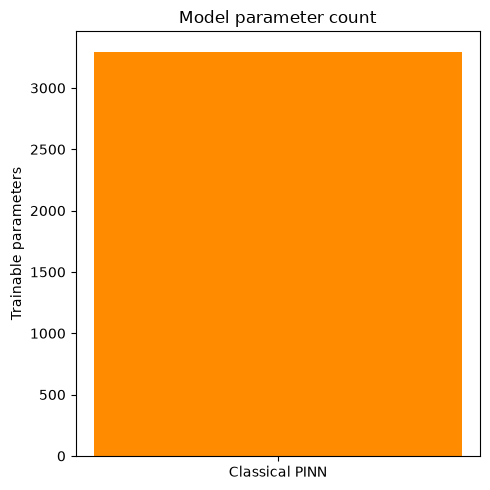

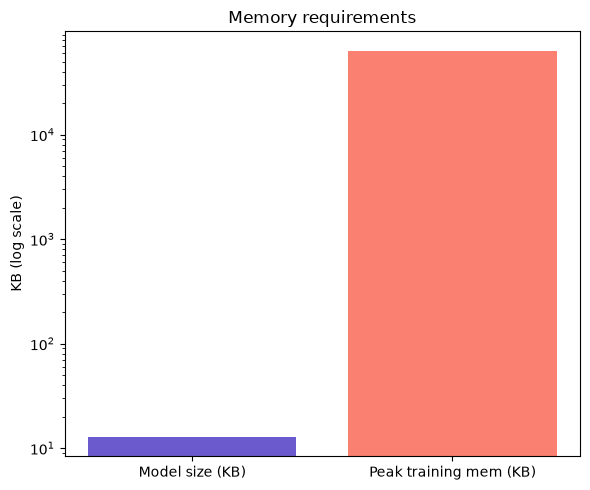

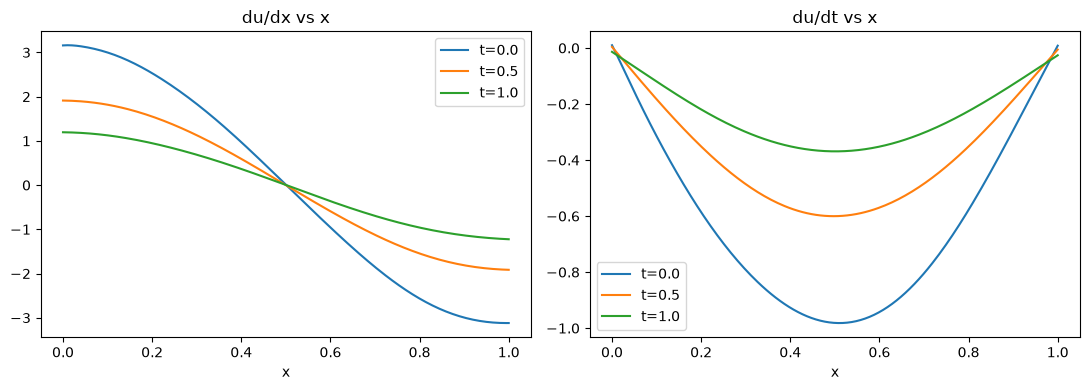

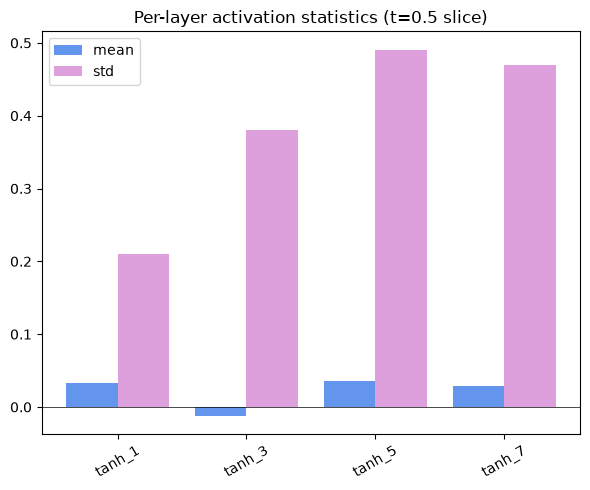

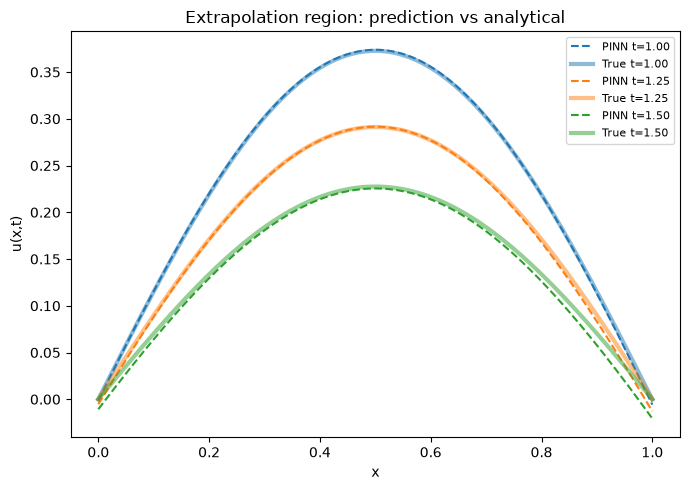

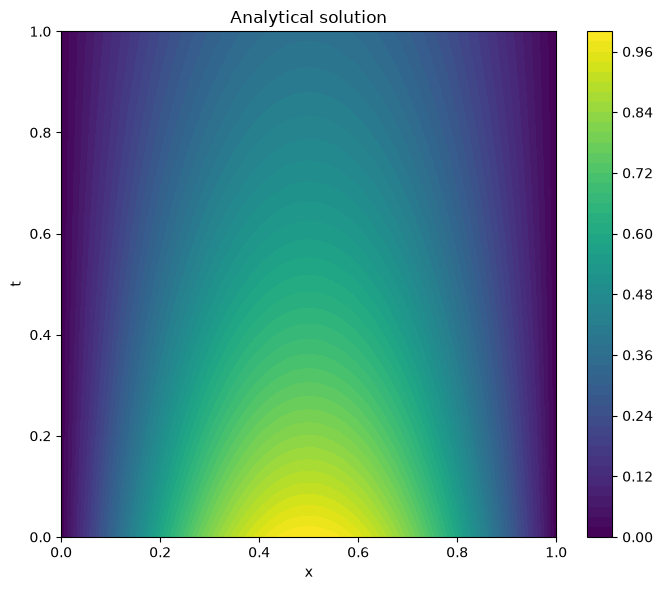

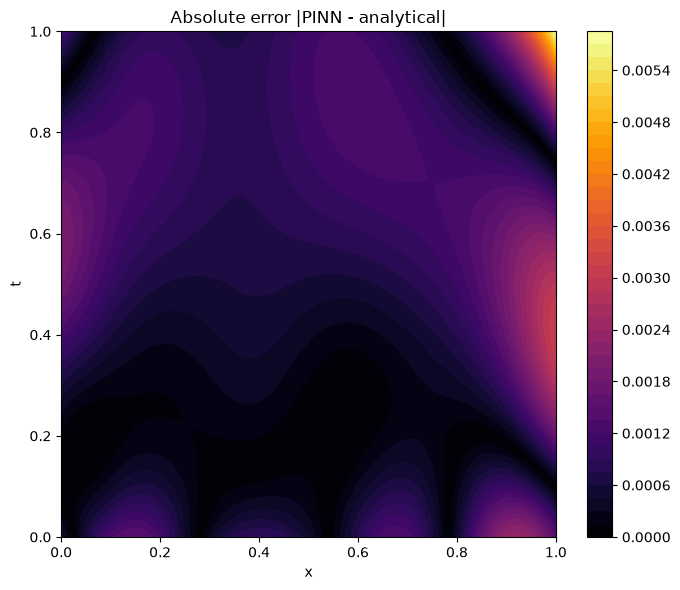

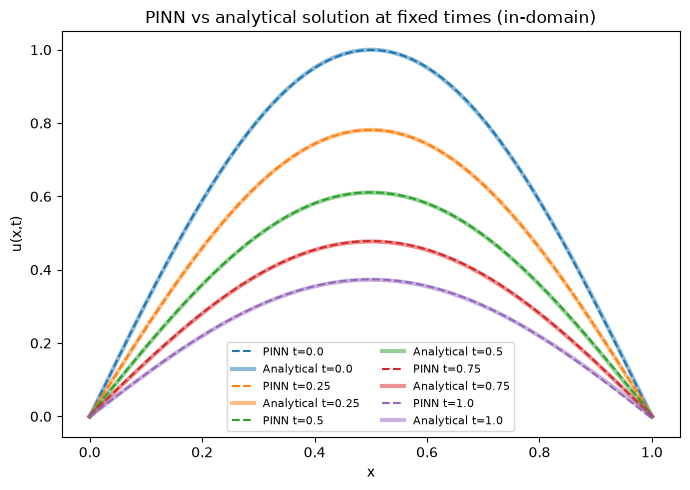


FINAL PDE RESIDUAL (dense grid, seed=42):
  MSE  = 2.979180e-05
  RMSE = 5.458187e-03



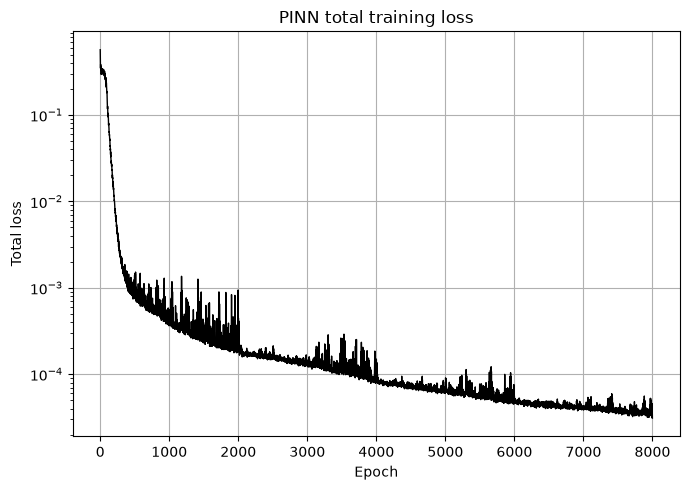

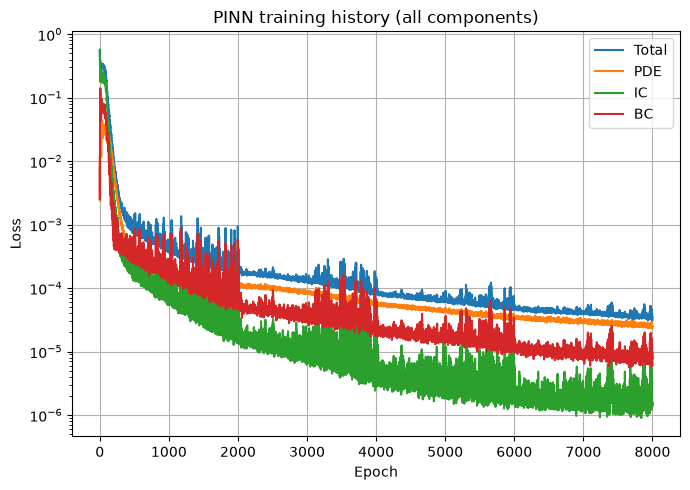

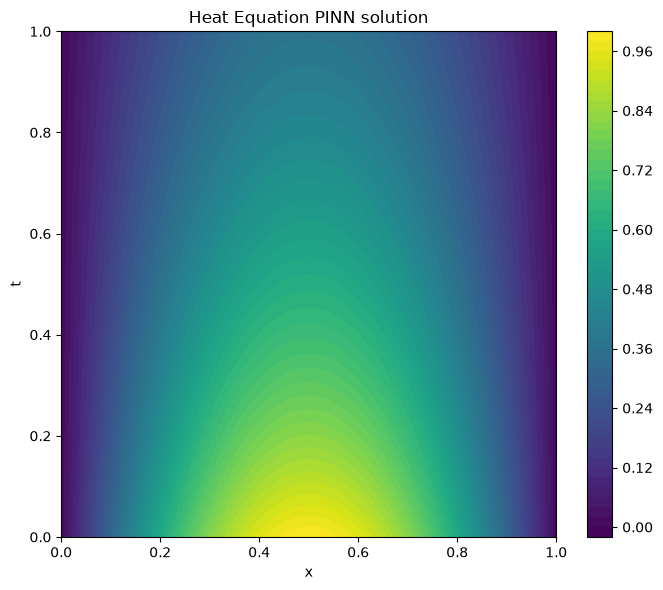

In [1]:
# ============================================================
# Classical Physics-Informed Neural Network (PINN)
# 1D Heat Equation
#
# PDE:      u_t - alpha * u_xx = 0,    x in [0,1], t in [0,T]
# IC:       u(x,0) = sin(pi*x)
# BC:       u(0,t) = u(1,t) = 0
#
# Analytical solution: u(x,t) = exp(-alpha*pi^2*t) * sin(pi*x)
#

import time
import tracemalloc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from scipy.stats.qmc import LatinHypercube


# ============================================================
# Configuration
# ============================================================

ALPHA = 0.1
T_FINAL = 1.0
T_EXTRAPOLATE = 1.5   # beyond this, the model has never seen data

EPOCHS = 8000
LEARNING_RATE = 1e-3

# Learning-rate decay: every LR_STEP_SIZE epochs, multiply LR by LR_GAMMA.
# Added because a fixed lr=1e-3 for the full training run was found to
# cause large, late-training loss spikes (especially in the BC term),
# leading to unstable, seed-dependent final accuracy. Step size scaled
# down proportionally with the reduced epoch budget (was 5000 at 20000
# epochs; 2000 keeps the same 4-step decay schedule at 8000 epochs).
LR_STEP_SIZE = 2000
LR_GAMMA = 0.5

N_F = 2000     # PDE collocation points
N_0 = 200      # Initial condition points
N_B = 200      # Boundary points

MAIN_SEED = 42   # seed for the detailed, plotted run


DEVICE = torch.device("cpu")
print("Device:", DEVICE)

# ============================================================
# Model
# ============================================================

class PINN(nn.Module):
    """
    Fully-connected network approximating u(x,t).
    Architecture: 2 -> 32 -> 32 -> 32 -> 32 -> 1, tanh activations.
    Tanh is used (not ReLU) because the PDE residual requires a
    second derivative of the network output w.r.t. its inputs;
    ReLU's second derivative is zero a.e. and undefined at the kink.
    """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1),
        )
        self._initialize()

    def _initialize(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


# ============================================================
# Collocation / IC / BC point sampling
# ============================================================

def sample_points(lhs_sampler, N_f, N_0, N_b, T):
    """
    Draws a fresh set of training points using the given (stateful)
    Latin Hypercube sampler. The sampler must be created ONCE per
    experiment and passed in on every call -- re-instantiating a
    fresh LatinHypercube(seed=...) inside this function would return
    the SAME points every call, silently disabling per-epoch
    resampling.
    """

    pts = lhs_sampler.random(N_f)
    x_f = pts[:, 0:1]
    t_f = pts[:, 1:2] * T

    x0 = np.random.rand(N_0, 1)
    t0 = np.zeros_like(x0)
    u0 = np.sin(np.pi * x0)

    tb = np.random.rand(N_b, 1) * T
    xb0 = np.zeros_like(tb)
    xb1 = np.ones_like(tb)

    to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=DEVICE)

    return (
        to_t(x_f), to_t(t_f),
        to_t(x0), to_t(t0), to_t(u0),
        to_t(xb0), to_t(xb1), to_t(tb),
    )


# ============================================================
# PDE residual via automatic differentiation
# ============================================================

def compute_residual(model, x, t, alpha):
    """
    f(x,t) = u_t - alpha * u_xx, computed via autograd.
    create_graph=True is required on every call here because u_x is
    differentiated again (w.r.t. x) to obtain u_xx.
    """
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(torch.cat([x, t], dim=1))

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    return u_t - alpha * u_xx


# ============================================================
# Loss function
# ============================================================

def loss_function(model, data, alpha, lambda_f=1.0, lambda_i=1.0, lambda_b=1.0):
    x_f, t_f, x0, t0, u0, xb0, xb1, tb = data

    residual = compute_residual(model, x_f, t_f, alpha)
    loss_pde = torch.mean(residual ** 2)

    u0_pred = model(torch.cat([x0, t0], dim=1))
    loss_ic = torch.mean((u0_pred - u0) ** 2)

    ub0 = model(torch.cat([xb0, tb], dim=1))
    ub1 = model(torch.cat([xb1, tb], dim=1))
    loss_bc = torch.mean(ub0 ** 2) + torch.mean(ub1 ** 2)

    total = lambda_f * loss_pde + lambda_i * loss_ic + lambda_b * loss_bc
    return total, loss_pde, loss_ic, loss_bc


# ============================================================
# Training loop
# ============================================================

def train(model, lhs_sampler, epochs=EPOCHS, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Decay LR over training: large steps early (fast progress), small
    # steps late (fine-tuning without kicking the solution off course).
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA
    )

    history = {"total": [], "pde": [], "ic": [], "bc": []}

    start = time.time()
    for epoch in range(epochs):
        data = sample_points(lhs_sampler, N_F, N_0, N_B, T_FINAL)

        optimizer.zero_grad()
        loss, lpde, lic, lbc = loss_function(model, data, ALPHA)
        loss.backward()
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["pde"].append(lpde.item())
        history["ic"].append(lic.item())
        history["bc"].append(lbc.item())

        if verbose and epoch % 1000 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch:6d} | total {loss.item():.3e} | "
                  f"pde {lpde.item():.3e} | ic {lic.item():.3e} | bc {lbc.item():.3e} | "
                  f"lr {current_lr:.1e}")

    training_time = time.time() - start
    return history, training_time


# ============================================================
# ============================================================

def exact_solution(x, t, alpha=ALPHA):
    return np.exp(-alpha * np.pi ** 2 * t) * np.sin(np.pi * x)


def evaluate(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2 = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return pred, true, X, Tt, L2


def pde_residual_error(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    residual = compute_residual(model, xt, tt, ALPHA).detach().cpu().numpy()
    mse = np.mean(residual ** 2)
    rmse = np.sqrt(mse)
    return mse, rmse, residual.reshape(X.shape), X, Tt


# ============================================================
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_memory_bytes(model):
    return sum(p.numel() * p.element_size() for p in model.parameters())


# ============================================================
# ============================================================

def sensitivity_slices(model, T=T_FINAL, times=(0.0, 0.5, 1.0), n_x=200):
    """u_x and u_t vs x, at a few fixed times."""
    x = np.linspace(0, 1, n_x)
    results = {}
    for t_val in times:
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32,
                            device=DEVICE, requires_grad=True)
        t_t = torch.full_like(x_t, t_val, requires_grad=True)
        u = model(torch.cat([x_t, t_t], dim=1))
        u_x = torch.autograd.grad(u, x_t, torch.ones_like(u), retain_graph=True)[0]
        u_t = torch.autograd.grad(u, t_t, torch.ones_like(u))[0]
        results[t_val] = (
            u_x.detach().cpu().numpy().flatten(),
            u_t.detach().cpu().numpy().flatten(),
        )
    return x, results


def activation_stats(model, t_val=0.5, n_x=20):
    """Mean/std of each tanh layer's output, at a fixed time slice."""
    x_sample = torch.linspace(0, 1, n_x, device=DEVICE).reshape(-1, 1)
    t_sample = torch.full_like(x_sample, t_val)

    activations = {}

    def hook_fn(name):
        def hook(module, inp, out):
            activations[name] = out.detach()
        return hook

    hooks = []
    for i, layer in enumerate(model.net):
        if isinstance(layer, nn.Tanh):
            hooks.append(layer.register_forward_hook(hook_fn(f"tanh_{i}")))

    with torch.no_grad():
        _ = model(torch.cat([x_sample, t_sample], dim=1))

    for h in hooks:
        h.remove()

    return {name: (act.mean().item(), act.std().item()) for name, act in activations.items()}


# ============================================================
# ============================================================

def extrapolation_test(model, T_train=T_FINAL, T_extra=T_EXTRAPOLATE, n_x=100, n_t=50):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(T_train, T_extra, n_t)   # region never seen during training
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2_extra = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return L2_extra, pred, true, X, Tt


# ============================================================
# ============================================================

def run_experiment(seed, epochs=EPOCHS, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    lhs_sampler = LatinHypercube(d=2, seed=seed)

    model = PINN().to(DEVICE)
    n_params = count_parameters(model)
    mem_bytes = model_memory_bytes(model)

    tracemalloc.start()
    history, training_time = train(model, lhs_sampler, epochs=epochs, verbose=verbose)
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    pred, true, X, Tt, l2_error = evaluate(model)
    mse_res, rmse_res, res_field, Xr, Ttr = pde_residual_error(model)
    l2_extra, pred_extra, true_extra, X_extra, Tt_extra = extrapolation_test(model)

    return {
        "seed": seed,
        "model": model,
        "history": history,
        "training_time": training_time,
        "n_params": n_params,
        "model_mem_kb": mem_bytes / 1024,
        "peak_mem_mb": peak_mem / 1024 ** 2,
        "l2_error": l2_error,
        "pde_mse": mse_res,
        "pde_rmse": rmse_res,
        "l2_extrapolation": l2_extra,
        "eval_grids": (pred, true, X, Tt),
        "residual_grid": (res_field, Xr, Ttr),
        "extrapolation_grids": (pred_extra, true_extra, X_extra, Tt_extra),
    }


# ============================================================
# ============================================================

if __name__ == "__main__":

    print(f"\n=== Detailed run (seed={MAIN_SEED}, epochs={EPOCHS}) ===")
    result = run_experiment(MAIN_SEED, epochs=EPOCHS, verbose=True)

    model = result["model"]
    history = result["history"]
    pred, true, X, Tt = result["eval_grids"]
    res_field, Xr, Ttr = result["residual_grid"]
    pred_extra, true_extra, X_extra, Tt_extra = result["extrapolation_grids"]

    print("\n==============================")
    print("Trainable parameters:      ", result["n_params"])
    print("Model memory (KB):         ", result["model_mem_kb"])
    print("Peak training memory (MB): ", result["peak_mem_mb"])
    print("Training time (s):         ", result["training_time"])
    print("Relative L2 error:         ", result["l2_error"])
    print("PDE residual MSE / RMSE:   ", result["pde_mse"], "/", result["pde_rmse"])
    print("Extrapolation L2 (t up to %.1f): %.4e" % (T_EXTRAPOLATE, result["l2_extrapolation"]))
    print("==============================\n")

    #  PDE residual, as error-vs-x slices ---
    plt.figure(figsize=(7, 5))
    for i, t_val in enumerate(np.linspace(0, T_FINAL, 5)):
        idx = int(t_val / T_FINAL * (Ttr.shape[0] - 1))
        plt.plot(Xr[idx], np.abs(res_field[idx]), label=f"t={t_val:.2f}")
    plt.xlabel("x"); plt.ylabel("|PDE residual|")
    plt.title("PDE residual vs x, at fixed times")
    plt.legend()
    plt.tight_layout()
    plt.savefig("metric1_pde_residual_slices.png", dpi=150)
    plt.show()

    #  Relative L2 error summary bar chart ---
    plt.figure(figsize=(5, 5))
    labels = ["In-domain L2", "Extrapolation L2"]
    values = [result["l2_error"], result["l2_extrapolation"]]
    bars = plt.bar(labels, values, color=["steelblue", "indianred"])
    plt.yscale("log")
    plt.ylabel("Relative L2 error")
    plt.title("Relative L2 error")
    for b, v in zip(bars, values):
        plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.2e}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig("metric2_l2_error.png", dpi=150)
    plt.show()

    #  training time ---
    plt.figure(figsize=(5, 5))
    plt.bar(["Classical PINN"], [result["training_time"]], color="seagreen")
    plt.ylabel("Training time (s)")
    plt.title(f"Training time ({EPOCHS} epochs)")
    plt.tight_layout()
    plt.savefig("metric3_training_time.png", dpi=150)
    plt.show()

    #  parameter count ---
    plt.figure(figsize=(5, 5))
    plt.bar(["Classical PINN"], [result["n_params"]], color="darkorange")
    plt.ylabel("Trainable parameters")
    plt.title("Model parameter count")
    plt.tight_layout()
    plt.savefig("metric4_param_count.png", dpi=150)
    plt.show()

    #  memory ---
    plt.figure(figsize=(6, 5))
    plt.bar(["Model size (KB)"], [result["model_mem_kb"]], color="slateblue")
    plt.bar(["Peak training mem (KB)"], [result["peak_mem_mb"] * 1024], color="salmon")
    plt.yscale("log")
    plt.ylabel("KB (log scale)")
    plt.title("Memory requirements")
    plt.tight_layout()
    plt.savefig("metric5_memory.png", dpi=150)
    plt.show()

    #  sensitivity slices ---
    x_s, sens = sensitivity_slices(model)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for t_val, (u_x, u_t) in sens.items():
        axes[0].plot(x_s, u_x, label=f"t={t_val}")
        axes[1].plot(x_s, u_t, label=f"t={t_val}")
    axes[0].set_title("du/dx vs x"); axes[0].set_xlabel("x"); axes[0].legend()
    axes[1].set_title("du/dt vs x"); axes[1].set_xlabel("x"); axes[1].legend()
    plt.tight_layout()
    plt.savefig("metric6a_sensitivity_slices.png", dpi=150)
    plt.show()

    #  activation stats ---
    stats = activation_stats(model)
    names = list(stats.keys())
    means = [stats[n][0] for n in names]
    stds = [stats[n][1] for n in names]
    x_pos = np.arange(len(names))
    plt.figure(figsize=(6, 5))
    plt.bar(x_pos - 0.2, means, width=0.4, label="mean", color="cornflowerblue")
    plt.bar(x_pos + 0.2, stds, width=0.4, label="std", color="plum")
    plt.xticks(x_pos, names, rotation=30)
    plt.axhline(0, color="black", linewidth=0.5)
    plt.title("Per-layer activation statistics (t=0.5 slice)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("metric6b_activation_stats.png", dpi=150)
    plt.show()

    #  extrapolation, as prediction-vs-true slices ---
    plt.figure(figsize=(7, 5))
    x = np.linspace(0, 1, 200)
    for t_val in (T_FINAL, (T_FINAL + T_EXTRAPOLATE) / 2, T_EXTRAPOLATE):
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        t_t = torch.full_like(x_t, t_val)
        with torch.no_grad():
            u_pred = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
        u_true = exact_solution(x, t_val)
        line, = plt.plot(x, u_pred, "--", label=f"PINN t={t_val:.2f}")
        plt.plot(x, u_true, color=line.get_color(), alpha=0.5, linewidth=3,
                 label=f"True t={t_val:.2f}")
    plt.xlabel("x"); plt.ylabel("u(x,t)")
    plt.title("Extrapolation region: prediction vs analytical")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("metric7_extrapolation_slices.png", dpi=150)
    plt.show()

    # --- Exact solution heatmap ---
    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X, Tt, true, levels=50, cmap="viridis")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Analytical solution")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("exact_solution_contour.png", dpi=150)
    plt.show()

    # --- Absolute error heatmap ---
    plt.figure(figsize=(7, 6))
    err_field = np.abs(pred - true)
    cf = plt.contourf(X, Tt, err_field, levels=50, cmap="inferno")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Absolute error |PINN - analytical|")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("absolute_error_contour.png", dpi=150)
    plt.show()

    # --- Slice comparison: PINN vs analytical, in-domain ---
    plt.figure(figsize=(7, 5))
    x = np.linspace(0, 1, 200)
    for t_val in (0.0, 0.25, 0.5, 0.75, 1.0):
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        t_t = torch.full_like(x_t, t_val)
        with torch.no_grad():
            u_pred = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
        u_true = exact_solution(x, t_val)
        line, = plt.plot(x, u_pred, "--", label=f"PINN t={t_val}")
        plt.plot(x, u_true, color=line.get_color(), alpha=0.5, linewidth=3,
                 label=f"Analytical t={t_val}")
    plt.xlabel("x"); plt.ylabel("u(x,t)")
    plt.title("PINN vs analytical solution at fixed times (in-domain)")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig("slice_comparison_indomain.png", dpi=150)
    plt.show()

    # --- Final PDE residual number, clearly reported ---
    print("\n==============================")
    print(f"FINAL PDE RESIDUAL (dense grid, seed={MAIN_SEED}):")
    print(f"  MSE  = {result['pde_mse']:.6e}")
    print(f"  RMSE = {result['pde_rmse']:.6e}")
    print("==============================\n")

    # --- Total loss history (clean summary curve) ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], color="black", linewidth=1)
    plt.xlabel("Epoch"); plt.ylabel("Total loss")
    plt.title("PINN total training loss")
    plt.grid()
    plt.tight_layout()
    plt.savefig("total_loss_history.png", dpi=150)
    plt.show()

    # --- All-component loss history ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], label="Total")
    plt.semilogy(history["pde"], label="PDE")
    plt.semilogy(history["ic"], label="IC")
    plt.semilogy(history["bc"], label="BC")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()
    plt.title("PINN training history (all components)")
    plt.grid()
    plt.tight_layout()
    plt.savefig("loss_history.png", dpi=150)
    plt.show()

    # --- PINN solution contour (prediction) ---
    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X, Tt, pred, levels=50, cmap="viridis")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Heat Equation PINN solution")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("solution_contour.png", dpi=150)
    plt.show()


result_full = result


Device: cpu

=== QAPINN detailed run (seed=42, epochs=8000) ===
Epoch      0 | total 2.139e+00 | pde 2.074e-05 | ic 2.207e-01 | bc 1.918e+00 | lr 1.0e-03
Epoch   1000 | total 3.140e-01 | pde 1.162e-02 | ic 2.258e-01 | bc 7.660e-02 | lr 1.0e-03
Epoch   2000 | total 3.088e-02 | pde 1.532e-02 | ic 1.120e-02 | bc 4.353e-03 | lr 5.0e-04
Epoch   3000 | total 9.517e-03 | pde 6.809e-03 | ic 1.873e-03 | bc 8.349e-04 | lr 5.0e-04
Epoch   4000 | total 2.590e-03 | pde 2.219e-03 | ic 2.399e-04 | bc 1.308e-04 | lr 2.5e-04
Epoch   5000 | total 1.612e-03 | pde 1.471e-03 | ic 7.893e-05 | bc 6.197e-05 | lr 2.5e-04
Epoch   6000 | total 8.080e-04 | pde 7.365e-04 | ic 3.253e-05 | bc 3.892e-05 | lr 1.3e-04
Epoch   7000 | total 6.375e-04 | pde 5.790e-04 | ic 2.349e-05 | bc 3.504e-05 | lr 1.3e-04

Trainable parameters:       50
Model memory (KB):          0.1953125
Peak training memory (MB):  1.8245391845703125
Training time (s):          5348.99454832077
Relative L2 error:          0.004508181233904578
PDE r

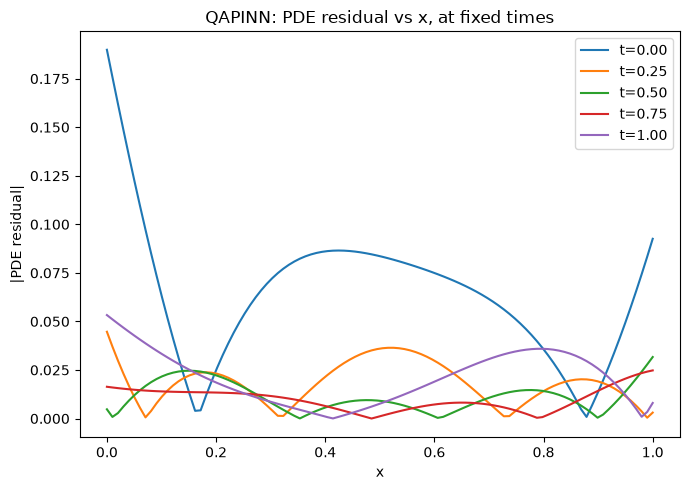

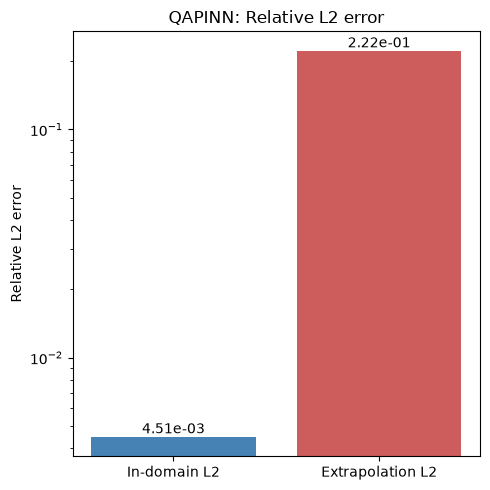

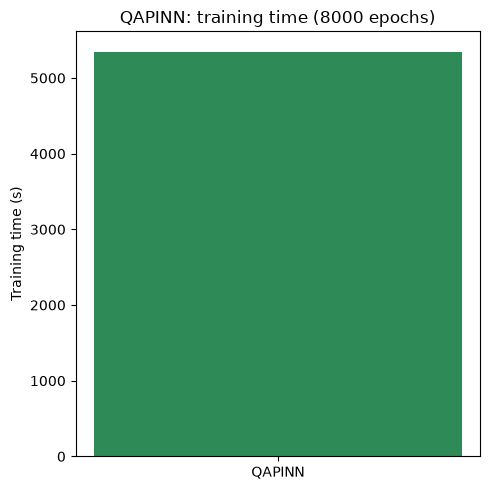

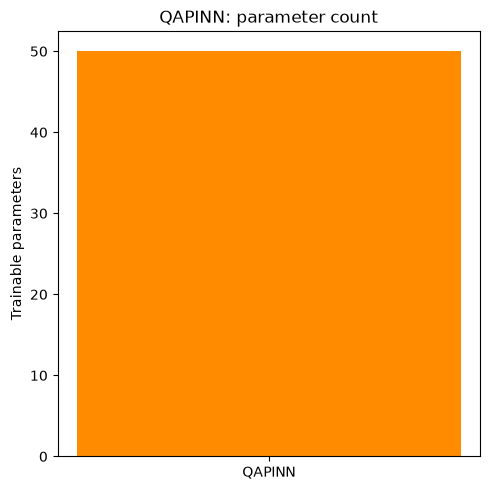

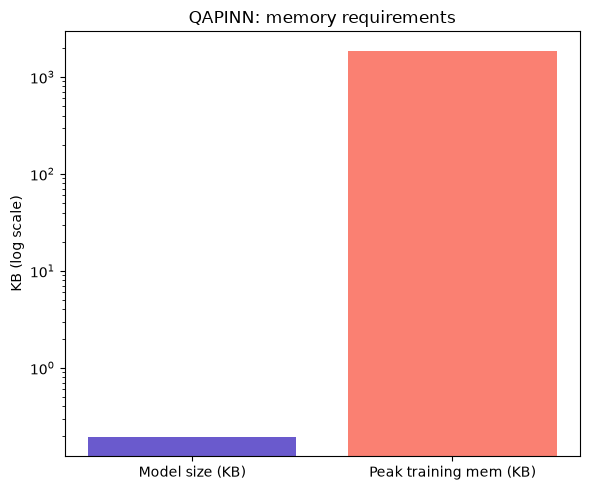

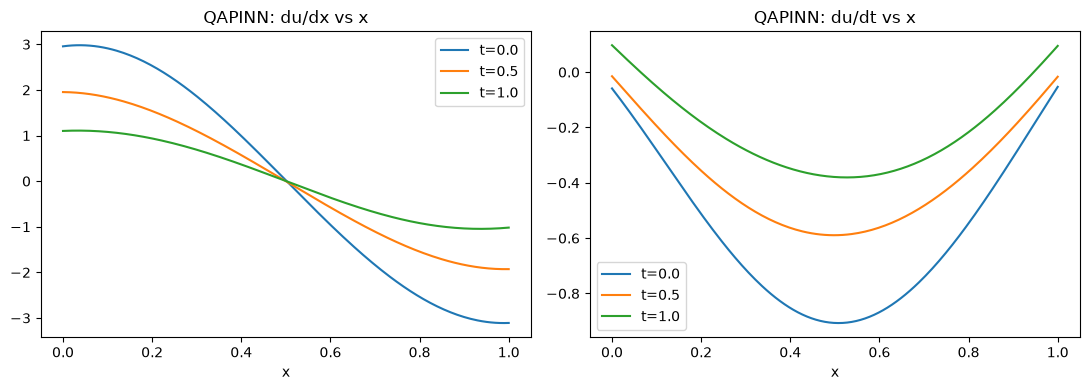

Quantum layer output (pre-readout) mean/std: (1.2818691730499268, 0.5423287749290466)


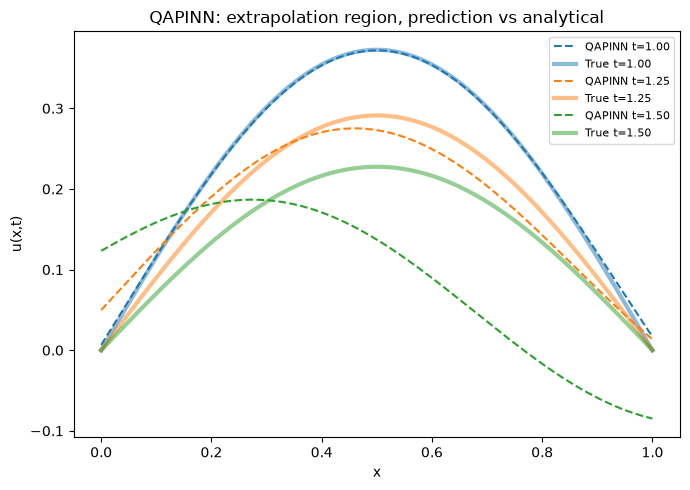

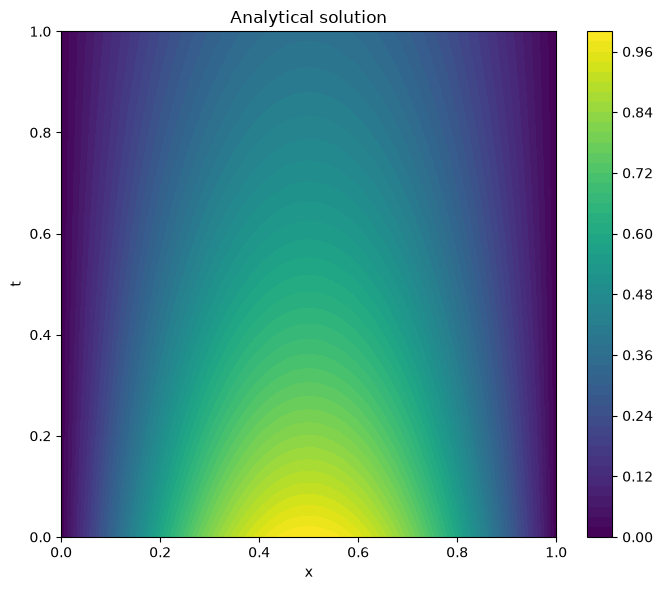

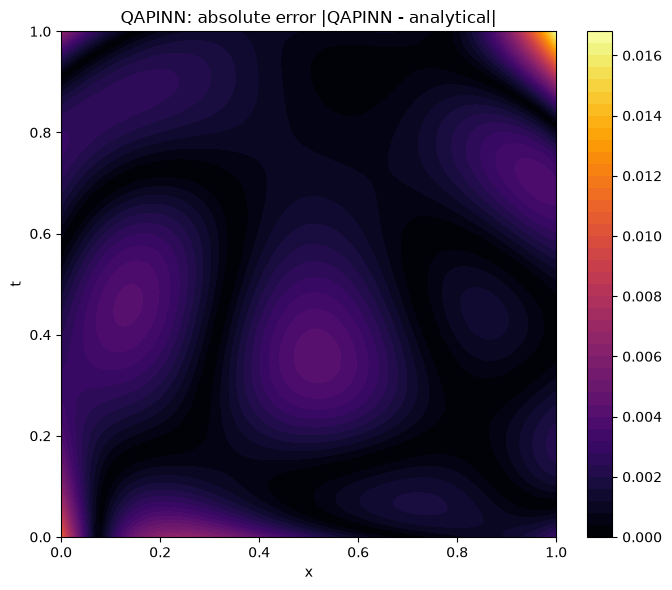

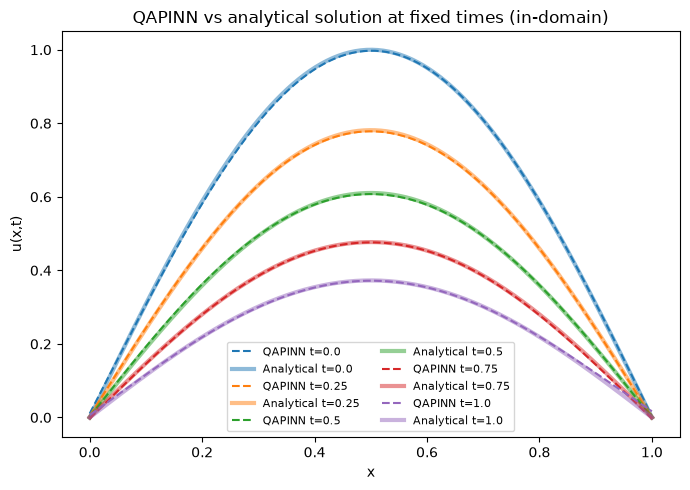


FINAL PDE RESIDUAL (dense grid, seed=42):
  MSE  = 5.053839e-04
  RMSE = 2.248075e-02



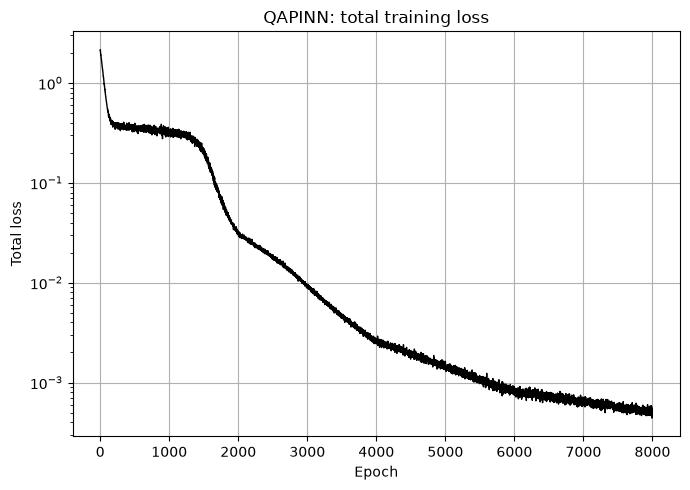

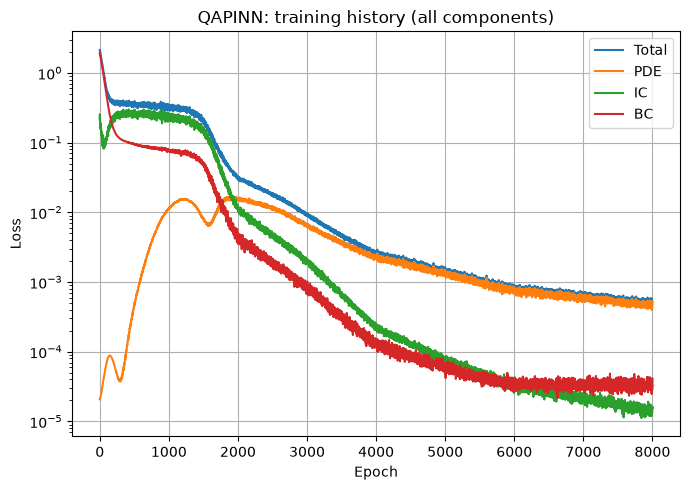

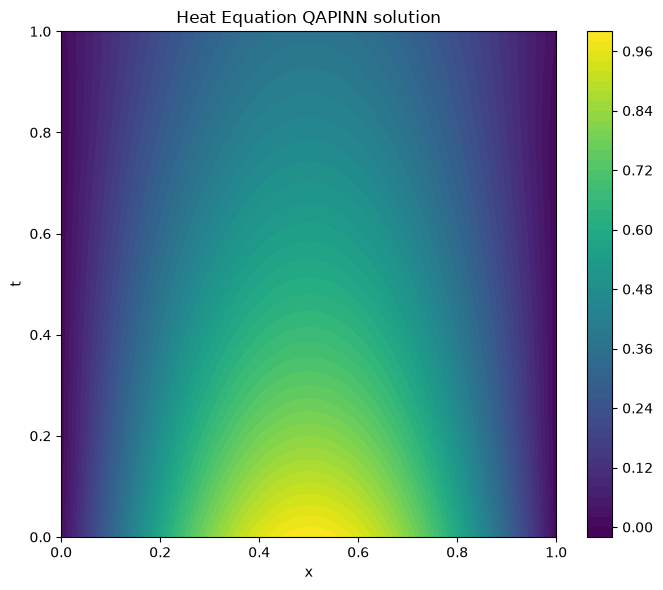

In [2]:
# ============================================================
# Quantum-Assisted Physics-Informed Neural Network (QAPINN)
# 1D Heat Equation -- PennyLane TorchLayer version
#
# PDE:      u_t - alpha * u_xx = 0,    x in [0,1], t in [0,T]
# IC:       u(x,0) = sin(pi*x)
# BC:       u(0,t) = u(1,t) = 0
#
# Circuit design:
#   - 4 qubits, 3 data re-uploading layers
#   - Encoding: RY(w_x * x), RZ(w_t * t) per qubit per layer (trainable
#     encoding weights)
#   - Variational: trainable RY, RZ per qubit per layer
#   - Entanglement: ring of CNOTs
#   - Measurement: sum of PauliZ over all qubits, expectation value
#   - Trainable affine readout (nn.Linear(1,1)) to calibrate output
#     scale/offset to the true solution's range
#
# Chosen over Qiskit's EstimatorQNN/TorchConnector after finding:
#   - parameter-shift gradients cost ~30s/epoch even for a tiny problem
#   - TorchConnector's backward is a non-differentiable custom Function,
#     so u_xx via double autograd was NOT possible (confirmed empirically)
# PennyLane's default.qubit + diff_method="backprop" fixes both: real
# autograd through the simulated statevector, no parameter-shift
# overhead in simulation, genuine double-backward support.
# ============================================================

import time
import tracemalloc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pennylane as qml

from scipy.stats.qmc import LatinHypercube


# ============================================================
# Configuration
# ============================================================

ALPHA = 0.1
T_FINAL = 1.0
T_EXTRAPOLATE = 1.5

N_QUBITS = 4
N_LAYERS = 3

EPOCHS = 8000
LEARNING_RATE = 1e-3
LR_STEP_SIZE = 2000
LR_GAMMA = 0.5

N_F = 2000
N_0 = 200
N_B = 200

MAIN_SEED = 42

DEVICE = torch.device("cpu")  
print("Device:", DEVICE)

QDEV = qml.device("default.qubit", wires=N_QUBITS)


# ============================================================
# Quantum circuit (data re-uploading), wrapped for TorchLayer
# ============================================================

def make_qnode():
    @qml.qnode(QDEV, interface="torch", diff_method="backprop")
    def circuit(inputs, w_x, w_t, theta_y, theta_z):
        """
        inputs: tensor of shape (..., 2) -- columns [x, t]. TorchLayer
                passes the batch through this single 'inputs' argument;
                all other arguments are trainable weights (declared via
                weight_shapes below).
        w_x, w_t, theta_y, theta_z: shape (N_LAYERS, N_QUBITS), trainable.
        """
        x = inputs[..., 0]
        t = inputs[..., 1]

        for layer in range(N_LAYERS):
            # Encoding sub-layer
            for q in range(N_QUBITS):
                qml.RY(w_x[layer, q] * x, wires=q)
                qml.RZ(w_t[layer, q] * t, wires=q)
            # Variational sub-layer
            for q in range(N_QUBITS):
                qml.RY(theta_y[layer, q], wires=q)
                qml.RZ(theta_z[layer, q], wires=q)
            # Entanglement: ring of CNOTs
            for q in range(N_QUBITS):
                qml.CNOT(wires=[q, (q + 1) % N_QUBITS])

        observable = qml.sum(*[qml.PauliZ(q) for q in range(N_QUBITS)])
        return qml.expval(observable)

    return circuit


WEIGHT_SHAPES = {
    "w_x": (N_LAYERS, N_QUBITS),
    "w_t": (N_LAYERS, N_QUBITS),
    "theta_y": (N_LAYERS, N_QUBITS),
    "theta_z": (N_LAYERS, N_QUBITS),
}


# ============================================================
# QAPINN model
# ============================================================

class QAPINN(nn.Module):
    """
    Hybrid QAPINN: PennyLane TorchLayer (data re-uploading quantum
    circuit) + trainable affine readout.

    Forward pass:
        (x,t) --> quantum circuit --> <sum Z_i> in [-4,4] --> affine --> u
    """

    def __init__(self):
        super().__init__()
        circuit = make_qnode()

        # init_method receives an *empty tensor* of the target shape (not a
        # shape tuple) and must return a filled tensor of the same shape --
        # nn.init.normal_ does exactly this, in place.
        self.quantum_layer = qml.qnn.TorchLayer(
            circuit, WEIGHT_SHAPES,
            init_method=lambda tensor: nn.init.normal_(tensor, mean=0.0, std=0.1),
        )

        self.readout = nn.Linear(1, 1)
        with torch.no_grad():
            self.readout.weight.fill_(0.25)   # roughly maps [-4,4] -> [-1,1] (4 qubits)
            self.readout.bias.zero_()

    def forward(self, xt):
        # xt: shape (N, 2), columns [x, t] -- same input format as the
        # classical PINN.
        q_out = self.quantum_layer(xt)          # shape (N,)
        q_out = q_out.reshape(-1, 1).to(torch.float32)
        u = self.readout(q_out)
        return u


# ============================================================
# Collocation / IC / BC sampling
# ============================================================

def sample_points(lhs_sampler, N_f, N_0, N_b, T):
    pts = lhs_sampler.random(N_f)
    x_f = pts[:, 0:1]
    t_f = pts[:, 1:2] * T

    x0 = np.random.rand(N_0, 1)
    t0 = np.zeros_like(x0)
    u0 = np.sin(np.pi * x0)

    tb = np.random.rand(N_b, 1) * T
    xb0 = np.zeros_like(tb)
    xb1 = np.ones_like(tb)

    to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=DEVICE)

    return (
        to_t(x_f), to_t(t_f),
        to_t(x0), to_t(t0), to_t(u0),
        to_t(xb0), to_t(xb1), to_t(tb),
    )


# ============================================================
# PDE residual -- exact autograd (double backward confirmed working)
# ============================================================

def compute_residual(model, x, t, alpha):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)

    u = model(torch.cat([x, t], dim=1))

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    return u_t - alpha * u_xx


# ============================================================
# Loss function
# ============================================================

def loss_function(model, data, alpha, lambda_f=1.0, lambda_i=1.0, lambda_b=1.0):
    x_f, t_f, x0, t0, u0, xb0, xb1, tb = data

    residual = compute_residual(model, x_f, t_f, alpha)
    loss_pde = torch.mean(residual ** 2)

    u0_pred = model(torch.cat([x0, t0], dim=1))
    loss_ic = torch.mean((u0_pred - u0) ** 2)

    ub0 = model(torch.cat([xb0, tb], dim=1))
    ub1 = model(torch.cat([xb1, tb], dim=1))
    loss_bc = torch.mean(ub0 ** 2) + torch.mean(ub1 ** 2)

    total = lambda_f * loss_pde + lambda_i * loss_ic + lambda_b * loss_bc
    return total, loss_pde, loss_ic, loss_bc


# ============================================================
# Training loop 
# ============================================================

def train(model, lhs_sampler, epochs=EPOCHS, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

    history = {"total": [], "pde": [], "ic": [], "bc": []}

    start = time.time()
    for epoch in range(epochs):
        data = sample_points(lhs_sampler, N_F, N_0, N_B, T_FINAL)

        optimizer.zero_grad()
        loss, lpde, lic, lbc = loss_function(model, data, ALPHA)
        loss.backward()
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["pde"].append(lpde.item())
        history["ic"].append(lic.item())
        history["bc"].append(lbc.item())

        if verbose and epoch % 1000 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch:6d} | total {loss.item():.3e} | "
                  f"pde {lpde.item():.3e} | ic {lic.item():.3e} | bc {lbc.item():.3e} | "
                  f"lr {current_lr:.1e}")

    training_time = time.time() - start
    return history, training_time


# ============================================================
#  PDE residual error + relative L2 error
# ============================================================

def exact_solution(x, t, alpha=ALPHA):
    return np.exp(-alpha * np.pi ** 2 * t) * np.sin(np.pi * x)


def evaluate(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2 = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return pred, true, X, Tt, L2


def pde_residual_error(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    residual = compute_residual(model, xt, tt, ALPHA).detach().cpu().numpy()
    mse = np.mean(residual ** 2)
    rmse = np.sqrt(mse)
    return mse, rmse, residual.reshape(X.shape), X, Tt


# ============================================================
#  parameter count and memory
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_memory_bytes(model):
    return sum(p.numel() * p.element_size() for p in model.parameters())


# ============================================================
#  Explainability
#
# Note on interpretation: the classical PINN's "per-layer activation
# stats" metric doesn't map 1:1 onto a single quantum circuit block --
# there isn't a stack of hidden layers to probe individually. The
# closest analogues used here:
#   (a) sensitivity slices: du/dx, du/dt vs x, at fixed t (same as
#       classical -- directly comparable)
#   (b) quantum-layer OUTPUT distribution (pre-readout): mean/std of
#       <sum Z_i> across a sample grid, i.e. how the circuit itself
#       (before classical calibration) uses its output range
# ============================================================

def sensitivity_slices(model, T=T_FINAL, times=(0.0, 0.5, 1.0), n_x=200):
    x = np.linspace(0, 1, n_x)
    results = {}
    for t_val in times:
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32,
                            device=DEVICE, requires_grad=True)
        t_t = torch.full_like(x_t, t_val, requires_grad=True)
        u = model(torch.cat([x_t, t_t], dim=1))
        u_x = torch.autograd.grad(u, x_t, torch.ones_like(u), retain_graph=True)[0]
        u_t = torch.autograd.grad(u, t_t, torch.ones_like(u))[0]
        results[t_val] = (
            u_x.detach().cpu().numpy().flatten(),
            u_t.detach().cpu().numpy().flatten(),
        )
    return x, results


def quantum_output_stats(model, n_x=20, n_t=20):
    """Mean/std of the quantum layer's raw output (pre-readout), across
    a grid of (x,t) -- the closest quantum analogue to 'activation stats'."""
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T_FINAL, n_t)
    X, Tt = np.meshgrid(x, t)
    xt = torch.tensor(
        np.stack([X.flatten(), Tt.flatten()], axis=1), dtype=torch.float32
    )
    with torch.no_grad():
        q_out = model.quantum_layer(xt)
    q_out = q_out.numpy()
    return {"quantum_output": (float(q_out.mean()), float(q_out.std()))}


# ============================================================
#  performance on unseen domain (temporal extrapolation)
# ============================================================

def extrapolation_test(model, T_train=T_FINAL, T_extra=T_EXTRAPOLATE, n_x=100, n_t=50):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(T_train, T_extra, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2_extra = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return L2_extra, pred, true, X, Tt


# ============================================================
# Single full experiment (train + all metrics), given a seed
# ============================================================

def run_experiment(seed, epochs=EPOCHS, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    lhs_sampler = LatinHypercube(d=2, seed=seed)

    model = QAPINN().to(DEVICE)
    n_params = count_parameters(model)
    mem_bytes = model_memory_bytes(model)

    tracemalloc.start()
    history, training_time = train(model, lhs_sampler, epochs=epochs, verbose=verbose)
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    pred, true, X, Tt, l2_error = evaluate(model)
    mse_res, rmse_res, res_field, Xr, Ttr = pde_residual_error(model)
    l2_extra, pred_extra, true_extra, X_extra, Tt_extra = extrapolation_test(model)

    return {
        "seed": seed,
        "model": model,
        "history": history,
        "training_time": training_time,
        "n_params": n_params,
        "model_mem_kb": mem_bytes / 1024,
        "peak_mem_mb": peak_mem / 1024 ** 2,
        "l2_error": l2_error,
        "pde_mse": mse_res,
        "pde_rmse": rmse_res,
        "l2_extrapolation": l2_extra,
        "eval_grids": (pred, true, X, Tt),
        "residual_grid": (res_field, Xr, Ttr),
        "extrapolation_grids": (pred_extra, true_extra, X_extra, Tt_extra),
    }


# ============================================================
# Run: single detailed run, all metrics and plots
# ============================================================

if __name__ == "__main__":

    print(f"\n=== QAPINN detailed run (seed={MAIN_SEED}, epochs={EPOCHS}) ===")
    result = run_experiment(MAIN_SEED, epochs=EPOCHS, verbose=True)

    model = result["model"]
    history = result["history"]
    pred, true, X, Tt = result["eval_grids"]
    res_field, Xr, Ttr = result["residual_grid"]
    pred_extra, true_extra, X_extra, Tt_extra = result["extrapolation_grids"]

    print("\n==============================")
    print("Trainable parameters:      ", result["n_params"])
    print("Model memory (KB):         ", result["model_mem_kb"])
    print("Peak training memory (MB): ", result["peak_mem_mb"])
    print("Training time (s):         ", result["training_time"])
    print("Relative L2 error:         ", result["l2_error"])
    print("PDE residual MSE / RMSE:   ", result["pde_mse"], "/", result["pde_rmse"])
    print("Extrapolation L2 (t up to %.1f): %.4e" % (T_EXTRAPOLATE, result["l2_extrapolation"]))
    print("==============================\n")

    #  PDE residual, as error-vs-x slices ---
    plt.figure(figsize=(7, 5))
    for t_val in np.linspace(0, T_FINAL, 5):
        idx = int(t_val / T_FINAL * (Ttr.shape[0] - 1))
        plt.plot(Xr[idx], np.abs(res_field[idx]), label=f"t={t_val:.2f}")
    plt.xlabel("x"); plt.ylabel("|PDE residual|")
    plt.title("QAPINN: PDE residual vs x, at fixed times")
    plt.legend()
    plt.tight_layout()
    plt.savefig("qapinn_metric1_pde_residual_slices.png", dpi=150)
    plt.show()

    #  Relative L2 error summary bar chart ---
    plt.figure(figsize=(5, 5))
    labels = ["In-domain L2", "Extrapolation L2"]
    values = [result["l2_error"], result["l2_extrapolation"]]
    bars = plt.bar(labels, values, color=["steelblue", "indianred"])
    plt.yscale("log")
    plt.ylabel("Relative L2 error")
    plt.title("QAPINN: Relative L2 error")
    for b, v in zip(bars, values):
        plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.2e}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig("qapinn_metric2_l2_error.png", dpi=150)
    plt.show()

    # training time ---
    plt.figure(figsize=(5, 5))
    plt.bar(["QAPINN"], [result["training_time"]], color="seagreen")
    plt.ylabel("Training time (s)")
    plt.title(f"QAPINN: training time ({EPOCHS} epochs)")
    plt.tight_layout()
    plt.savefig("qapinn_metric3_training_time.png", dpi=150)
    plt.show()

    # parameter count ---
    plt.figure(figsize=(5, 5))
    plt.bar(["QAPINN"], [result["n_params"]], color="darkorange")
    plt.ylabel("Trainable parameters")
    plt.title("QAPINN: parameter count")
    plt.tight_layout()
    plt.savefig("qapinn_metric4_param_count.png", dpi=150)
    plt.show()

    #  memory ---
    plt.figure(figsize=(6, 5))
    plt.bar(["Model size (KB)"], [result["model_mem_kb"]], color="slateblue")
    plt.bar(["Peak training mem (KB)"], [result["peak_mem_mb"] * 1024], color="salmon")
    plt.yscale("log")
    plt.ylabel("KB (log scale)")
    plt.title("QAPINN: memory requirements")
    plt.tight_layout()
    plt.savefig("qapinn_metric5_memory.png", dpi=150)
    plt.show()

    #  sensitivity slices ---
    x_s, sens = sensitivity_slices(model)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for t_val, (u_x, u_t) in sens.items():
        axes[0].plot(x_s, u_x, label=f"t={t_val}")
        axes[1].plot(x_s, u_t, label=f"t={t_val}")
    axes[0].set_title("QAPINN: du/dx vs x"); axes[0].set_xlabel("x"); axes[0].legend()
    axes[1].set_title("QAPINN: du/dt vs x"); axes[1].set_xlabel("x"); axes[1].legend()
    plt.tight_layout()
    plt.savefig("qapinn_metric6a_sensitivity_slices.png", dpi=150)
    plt.show()

    #  quantum output distribution (pre-readout) ---
    q_stats = quantum_output_stats(model)
    print("Quantum layer output (pre-readout) mean/std:", q_stats["quantum_output"])

    # extrapolation, as prediction-vs-true slices ---
    plt.figure(figsize=(7, 5))
    x = np.linspace(0, 1, 200)
    for t_val in (T_FINAL, (T_FINAL + T_EXTRAPOLATE) / 2, T_EXTRAPOLATE):
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        t_t = torch.full_like(x_t, t_val)
        with torch.no_grad():
            u_pred = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
        u_true = exact_solution(x, t_val)
        line, = plt.plot(x, u_pred, "--", label=f"QAPINN t={t_val:.2f}")
        plt.plot(x, u_true, color=line.get_color(), alpha=0.5, linewidth=3,
                 label=f"True t={t_val:.2f}")
    plt.xlabel("x"); plt.ylabel("u(x,t)")
    plt.title("QAPINN: extrapolation region, prediction vs analytical")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("qapinn_metric7_extrapolation_slices.png", dpi=150)
    plt.show()

    # --- Exact solution heatmap ---
    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X, Tt, true, levels=50, cmap="viridis")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Analytical solution")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("qapinn_exact_solution_contour.png", dpi=150)
    plt.show()

    # --- Absolute error heatmap ---
    plt.figure(figsize=(7, 6))
    err_field = np.abs(pred - true)
    cf = plt.contourf(X, Tt, err_field, levels=50, cmap="inferno")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("QAPINN: absolute error |QAPINN - analytical|")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("qapinn_absolute_error_contour.png", dpi=150)
    plt.show()

    # --- Slice comparison: QAPINN vs analytical, in-domain ---
    plt.figure(figsize=(7, 5))
    x = np.linspace(0, 1, 200)
    for t_val in (0.0, 0.25, 0.5, 0.75, 1.0):
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        t_t = torch.full_like(x_t, t_val)
        with torch.no_grad():
            u_pred = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
        u_true = exact_solution(x, t_val)
        line, = plt.plot(x, u_pred, "--", label=f"QAPINN t={t_val}")
        plt.plot(x, u_true, color=line.get_color(), alpha=0.5, linewidth=3,
                 label=f"Analytical t={t_val}")
    plt.xlabel("x"); plt.ylabel("u(x,t)")
    plt.title("QAPINN vs analytical solution at fixed times (in-domain)")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig("qapinn_slice_comparison_indomain.png", dpi=150)
    plt.show()

    # --- Final PDE residual number, clearly reported ---
    print("\n==============================")
    print(f"FINAL PDE RESIDUAL (dense grid, seed={MAIN_SEED}):")
    print(f"  MSE  = {result['pde_mse']:.6e}")
    print(f"  RMSE = {result['pde_rmse']:.6e}")
    print("==============================\n")

    # --- Total loss history ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], color="black", linewidth=1)
    plt.xlabel("Epoch"); plt.ylabel("Total loss")
    plt.title("QAPINN: total training loss")
    plt.grid()
    plt.tight_layout()
    plt.savefig("qapinn_total_loss_history.png", dpi=150)
    plt.show()

    # --- All-component loss history ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], label="Total")
    plt.semilogy(history["pde"], label="PDE")
    plt.semilogy(history["ic"], label="IC")
    plt.semilogy(history["bc"], label="BC")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()
    plt.title("QAPINN: training history (all components)")
    plt.grid()
    plt.tight_layout()
    plt.savefig("qapinn_loss_history.png", dpi=150)
    plt.show()

    # --- QAPINN solution contour (prediction) ---
    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X, Tt, pred, levels=50, cmap="viridis")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Heat Equation QAPINN solution")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("qapinn_solution_contour.png", dpi=150)
    plt.show()


result_qapinn = result


Device: cpu

=== Small classical PINN control (width=12, seed=42, epochs=8000) ===
Epoch      0 | total 6.406e-01 | pde 1.057e-01 | ic 3.705e-01 | bc 1.645e-01 | lr 1.0e-03
Epoch   1000 | total 9.180e-02 | pde 1.078e-02 | ic 5.506e-02 | bc 2.595e-02 | lr 1.0e-03
Epoch   2000 | total 3.430e-02 | pde 7.399e-03 | ic 9.878e-03 | bc 1.703e-02 | lr 5.0e-04
Epoch   3000 | total 2.139e-02 | pde 4.266e-03 | ic 6.243e-03 | bc 1.088e-02 | lr 5.0e-04
Epoch   4000 | total 1.213e-02 | pde 3.152e-03 | ic 2.865e-03 | bc 6.117e-03 | lr 2.5e-04
Epoch   5000 | total 8.980e-03 | pde 2.686e-03 | ic 2.269e-03 | bc 4.025e-03 | lr 2.5e-04
Epoch   6000 | total 6.448e-03 | pde 2.730e-03 | ic 1.312e-03 | bc 2.406e-03 | lr 1.3e-04
Epoch   7000 | total 5.624e-03 | pde 2.743e-03 | ic 1.041e-03 | bc 1.840e-03 | lr 1.3e-04

Trainable parameters:       49 (QAPINN: 50)
Model memory (KB):          0.19140625
Peak training memory (MB):  1.1581697463989258
Training time (s):          33.085185050964355
Relative L2 error: 

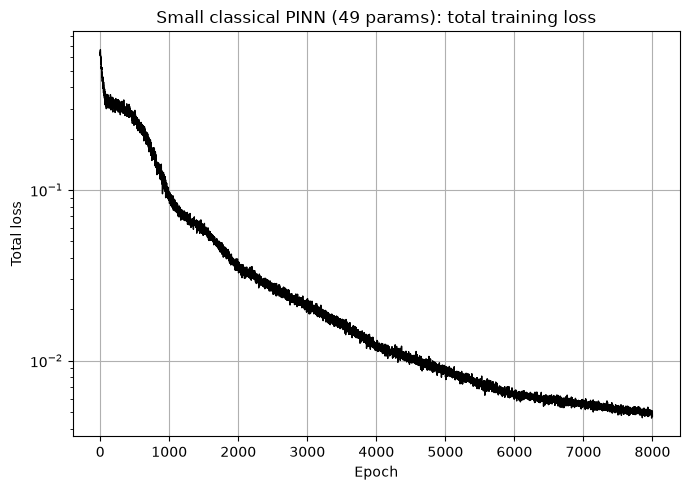

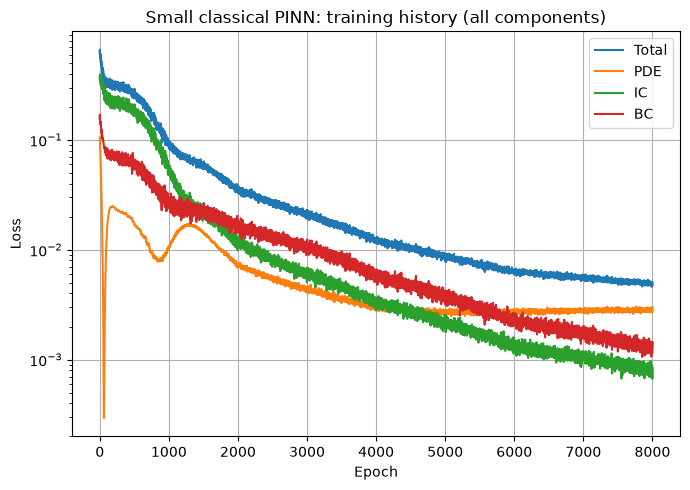

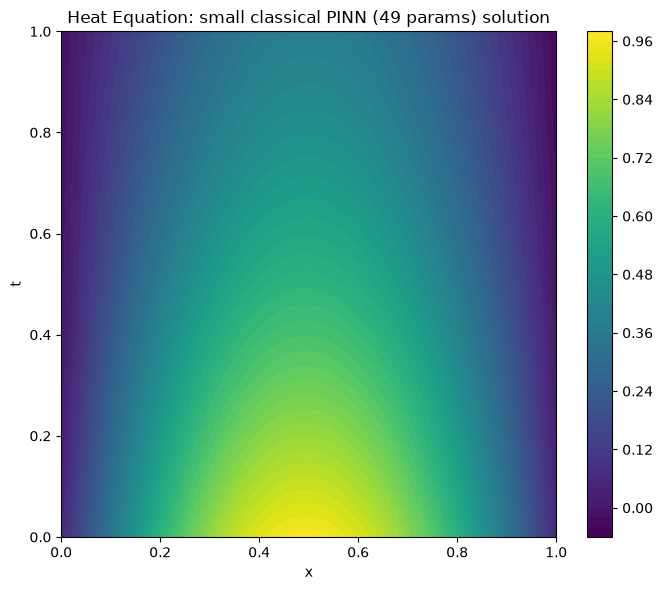

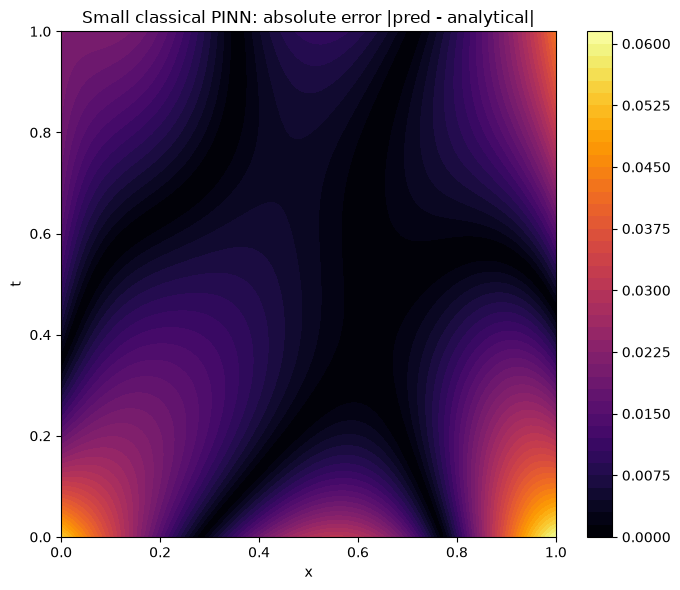

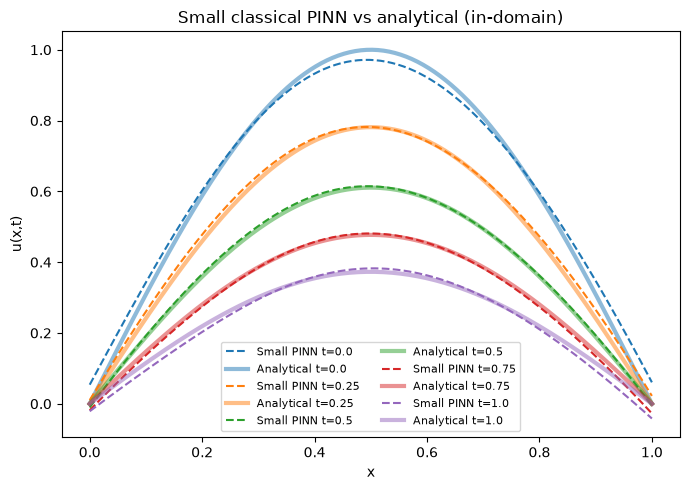

In [4]:
# ============================================================
# Classical Physics-Informed Neural Network (PINN)
# 1D Heat Equation
#
# PDE:      u_t - alpha * u_xx = 0,    x in [0,1], t in [0,T]
# IC:       u(x,0) = sin(pi*x)
# BC:       u(0,t) = u(1,t) = 0
#
# Analytical solution: u(x,t) = exp(-alpha*pi^2*t) * sin(pi*x)
#
#Architecture: 2 -> 12 -> 1 (single hidden layer, tanh)
#   params = (2*12 + 12) + (12*1 + 1) = 36 + 13 = 49

import time
import tracemalloc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from scipy.stats.qmc import LatinHypercube


# ============================================================
# Configuration
# ============================================================

ALPHA = 0.1
T_FINAL = 1.0
T_EXTRAPOLATE = 1.5   # beyond this, the model has never seen data

EPOCHS = 8000
LEARNING_RATE = 1e-3


LR_STEP_SIZE = 2000
LR_GAMMA = 0.5

N_F = 2000     # PDE collocation points
N_0 = 200      # Initial condition points
N_B = 200      # Boundary points

MAIN_SEED = 42   # seed for the detailed, plotted run
HIDDEN_WIDTH = 12 


DEVICE = torch.device("cpu")
print("Device:", DEVICE)


# ============================================================
# Model
# ============================================================

class SmallPINN(nn.Module):
    """
    Capacity-matched control: 2 -> HIDDEN_WIDTH -> 1, single tanh
    hidden layer. ~49 trainable parameters, matched to the QAPINN's 50.
    """

    def __init__(self, width=HIDDEN_WIDTH):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, width), nn.Tanh(),
            nn.Linear(width, 1),
        )
        self._initialize()

    def _initialize(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


# ============================================================
# Collocation / IC / BC point sampling
# ============================================================

def sample_points(lhs_sampler, N_f, N_0, N_b, T):
    """
    Draws a fresh set of training points using the given (stateful)
    Latin Hypercube sampler. The sampler must be created ONCE per
    experiment and passed in on every call -- re-instantiating a
    fresh LatinHypercube(seed=...) inside this function would return
    the SAME points every call, silently disabling per-epoch
    resampling.
    """

    pts = lhs_sampler.random(N_f)
    x_f = pts[:, 0:1]
    t_f = pts[:, 1:2] * T

    x0 = np.random.rand(N_0, 1)
    t0 = np.zeros_like(x0)
    u0 = np.sin(np.pi * x0)

    tb = np.random.rand(N_b, 1) * T
    xb0 = np.zeros_like(tb)
    xb1 = np.ones_like(tb)

    to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=DEVICE)

    return (
        to_t(x_f), to_t(t_f),
        to_t(x0), to_t(t0), to_t(u0),
        to_t(xb0), to_t(xb1), to_t(tb),
    )


# ============================================================
# PDE residual via automatic differentiation
# ============================================================

def compute_residual(model, x, t, alpha):
    """
    f(x,t) = u_t - alpha * u_xx, computed via autograd.
    create_graph=True is required on every call here because u_x is
    differentiated again (w.r.t. x) to obtain u_xx.
    """
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(torch.cat([x, t], dim=1))

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    return u_t - alpha * u_xx


# ============================================================
# Loss function
# ============================================================

def loss_function(model, data, alpha, lambda_f=1.0, lambda_i=1.0, lambda_b=1.0):
    x_f, t_f, x0, t0, u0, xb0, xb1, tb = data

    residual = compute_residual(model, x_f, t_f, alpha)
    loss_pde = torch.mean(residual ** 2)

    u0_pred = model(torch.cat([x0, t0], dim=1))
    loss_ic = torch.mean((u0_pred - u0) ** 2)

    ub0 = model(torch.cat([xb0, tb], dim=1))
    ub1 = model(torch.cat([xb1, tb], dim=1))
    loss_bc = torch.mean(ub0 ** 2) + torch.mean(ub1 ** 2)

    total = lambda_f * loss_pde + lambda_i * loss_ic + lambda_b * loss_bc
    return total, loss_pde, loss_ic, loss_bc


# ============================================================
# Training loop
# ============================================================

def train(model, lhs_sampler, epochs=EPOCHS, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Decay LR over training: large steps early (fast progress), small
    # steps late (fine-tuning without kicking the solution off course).
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA
    )

    history = {"total": [], "pde": [], "ic": [], "bc": []}

    start = time.time()
    for epoch in range(epochs):
        data = sample_points(lhs_sampler, N_F, N_0, N_B, T_FINAL)

        optimizer.zero_grad()
        loss, lpde, lic, lbc = loss_function(model, data, ALPHA)
        loss.backward()
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["pde"].append(lpde.item())
        history["ic"].append(lic.item())
        history["bc"].append(lbc.item())

        if verbose and epoch % 1000 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch:6d} | total {loss.item():.3e} | "
                  f"pde {lpde.item():.3e} | ic {lic.item():.3e} | bc {lbc.item():.3e} | "
                  f"lr {current_lr:.1e}")

    training_time = time.time() - start
    return history, training_time


# ============================================================
# ============================================================

def exact_solution(x, t, alpha=ALPHA):
    return np.exp(-alpha * np.pi ** 2 * t) * np.sin(np.pi * x)


def evaluate(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2 = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return pred, true, X, Tt, L2


def pde_residual_error(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    residual = compute_residual(model, xt, tt, ALPHA).detach().cpu().numpy()
    mse = np.mean(residual ** 2)
    rmse = np.sqrt(mse)
    return mse, rmse, residual.reshape(X.shape), X, Tt


# ============================================================
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_memory_bytes(model):
    return sum(p.numel() * p.element_size() for p in model.parameters())


# ============================================================
# ============================================================

def sensitivity_slices(model, T=T_FINAL, times=(0.0, 0.5, 1.0), n_x=200):
    """u_x and u_t vs x, at a few fixed times."""
    x = np.linspace(0, 1, n_x)
    results = {}
    for t_val in times:
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32,
                            device=DEVICE, requires_grad=True)
        t_t = torch.full_like(x_t, t_val, requires_grad=True)
        u = model(torch.cat([x_t, t_t], dim=1))
        u_x = torch.autograd.grad(u, x_t, torch.ones_like(u), retain_graph=True)[0]
        u_t = torch.autograd.grad(u, t_t, torch.ones_like(u))[0]
        results[t_val] = (
            u_x.detach().cpu().numpy().flatten(),
            u_t.detach().cpu().numpy().flatten(),
        )
    return x, results


def activation_stats(model, t_val=0.5, n_x=20):
    """Mean/std of each tanh layer's output, at a fixed time slice."""
    x_sample = torch.linspace(0, 1, n_x, device=DEVICE).reshape(-1, 1)
    t_sample = torch.full_like(x_sample, t_val)

    activations = {}

    def hook_fn(name):
        def hook(module, inp, out):
            activations[name] = out.detach()
        return hook

    hooks = []
    for i, layer in enumerate(model.net):
        if isinstance(layer, nn.Tanh):
            hooks.append(layer.register_forward_hook(hook_fn(f"tanh_{i}")))

    with torch.no_grad():
        _ = model(torch.cat([x_sample, t_sample], dim=1))

    for h in hooks:
        h.remove()

    return {name: (act.mean().item(), act.std().item()) for name, act in activations.items()}


# ============================================================
# ============================================================

def extrapolation_test(model, T_train=T_FINAL, T_extra=T_EXTRAPOLATE, n_x=100, n_t=50):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(T_train, T_extra, n_t)   # region never seen during training
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2_extra = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return L2_extra, pred, true, X, Tt


# ============================================================
# ============================================================

def run_experiment(seed, epochs=EPOCHS, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    lhs_sampler = LatinHypercube(d=2, seed=seed)

    model = SmallPINN().to(DEVICE)
    n_params = count_parameters(model)
    mem_bytes = model_memory_bytes(model)

    tracemalloc.start()
    history, training_time = train(model, lhs_sampler, epochs=epochs, verbose=verbose)
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    pred, true, X, Tt, l2_error = evaluate(model)
    mse_res, rmse_res, res_field, Xr, Ttr = pde_residual_error(model)
    l2_extra, pred_extra, true_extra, X_extra, Tt_extra = extrapolation_test(model)

    return {
        "seed": seed,
        "model": model,
        "history": history,
        "training_time": training_time,
        "n_params": n_params,
        "model_mem_kb": mem_bytes / 1024,
        "peak_mem_mb": peak_mem / 1024 ** 2,
        "l2_error": l2_error,
        "pde_mse": mse_res,
        "pde_rmse": rmse_res,
        "l2_extrapolation": l2_extra,
        "eval_grids": (pred, true, X, Tt),
        "residual_grid": (res_field, Xr, Ttr),
        "extrapolation_grids": (pred_extra, true_extra, X_extra, Tt_extra),
    }


# ============================================================
# Run
# ============================================================

if __name__ == "__main__":

    print(f"\n=== Small classical PINN control (width={HIDDEN_WIDTH}, "
          f"seed={MAIN_SEED}, epochs={EPOCHS}) ===")
    result = run_experiment(MAIN_SEED, epochs=EPOCHS, verbose=True)

    model = result["model"]
    history = result["history"]
    pred, true, X, Tt = result["eval_grids"]
    res_field, Xr, Ttr = result["residual_grid"]

    print("\n==============================")
    print("Trainable parameters:      ", result["n_params"], "(QAPINN: 50)")
    print("Model memory (KB):         ", result["model_mem_kb"])
    print("Peak training memory (MB): ", result["peak_mem_mb"])
    print("Training time (s):         ", result["training_time"])
    print("Relative L2 error:         ", result["l2_error"])
    print("PDE residual MSE / RMSE:   ", result["pde_mse"], "/", result["pde_rmse"])
    print("Extrapolation L2 (t up to %.1f): %.4e" % (T_EXTRAPOLATE, result["l2_extrapolation"]))
    print("==============================\n")

    # --- Total loss history ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], color="black", linewidth=1)
    plt.xlabel("Epoch"); plt.ylabel("Total loss")
    plt.title(f"Small classical PINN ({result['n_params']} params): total training loss")
    plt.grid()
    plt.tight_layout()
    plt.savefig("small_total_loss_history.png", dpi=150)
    plt.show()

    # --- All-component loss history ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], label="Total")
    plt.semilogy(history["pde"], label="PDE")
    plt.semilogy(history["ic"], label="IC")
    plt.semilogy(history["bc"], label="BC")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()
    plt.title("Small classical PINN: training history (all components)")
    plt.grid()
    plt.tight_layout()
    plt.savefig("small_loss_history.png", dpi=150)
    plt.show()

    # --- Solution contour ---
    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X, Tt, pred, levels=50, cmap="viridis")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title(f"Heat Equation: small classical PINN ({result['n_params']} params) solution")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("small_solution_contour.png", dpi=150)
    plt.show()

    # --- Absolute error heatmap ---
    plt.figure(figsize=(7, 6))
    err_field = np.abs(pred - true)
    cf = plt.contourf(X, Tt, err_field, levels=50, cmap="inferno")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Small classical PINN: absolute error |pred - analytical|")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("small_absolute_error_contour.png", dpi=150)
    plt.show()

    # --- Slice comparison ---
    plt.figure(figsize=(7, 5))
    x = np.linspace(0, 1, 200)
    for t_val in (0.0, 0.25, 0.5, 0.75, 1.0):
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        t_t = torch.full_like(x_t, t_val)
        with torch.no_grad():
            u_pred = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
        u_true = exact_solution(x, t_val)
        line, = plt.plot(x, u_pred, "--", label=f"Small PINN t={t_val}")
        plt.plot(x, u_true, color=line.get_color(), alpha=0.5, linewidth=3,
                 label=f"Analytical t={t_val}")
    plt.xlabel("x"); plt.ylabel("u(x,t)")
    plt.title("Small classical PINN vs analytical (in-domain)")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig("small_slice_comparison_indomain.png", dpi=150)
    plt.show()


result_small = result

Metric                              Full classical   Small classical            QAPINN
--------------------------------------------------------------------------------------
Trainable parameters                          3297                49                50
Relative L2 error (in-domain)               0.0021            0.0294            0.0045
PDE residual MSE                        2.9792e-05            0.0030        5.0538e-04
PDE residual RMSE                           0.0055            0.0548            0.0225
Extrapolation L2 error                      0.0212            0.1073            0.2216
Training time (s)                          97.1997           33.0852         5348.9945
Model memory (KB)                          12.8789            0.1914            0.1953
Peak training memory (MB)                  62.1137            1.1582            1.8245

Derived metrics:
  Full classical     accuracy-per-param (1/(L2*params)): 1.416e-01   accuracy-per-second (1/(L2*time)): 4.801e+0

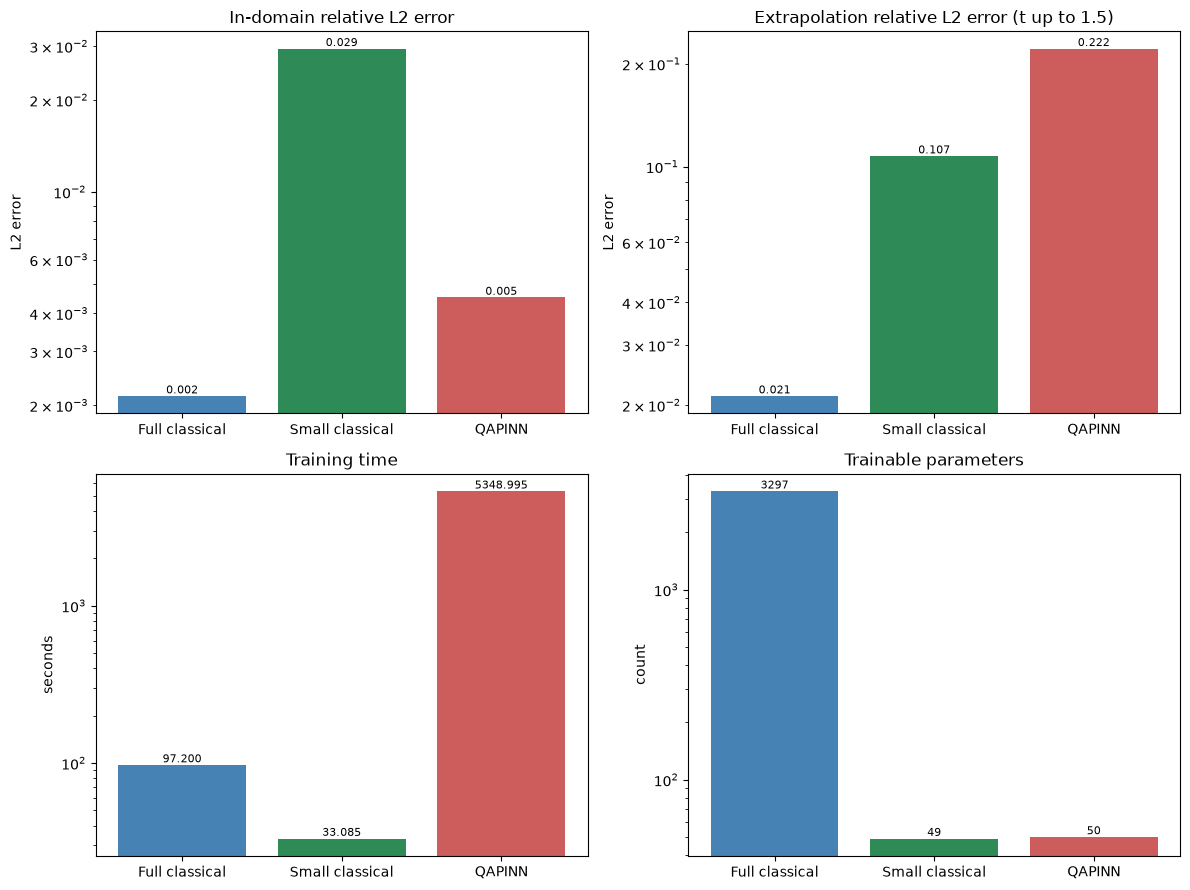

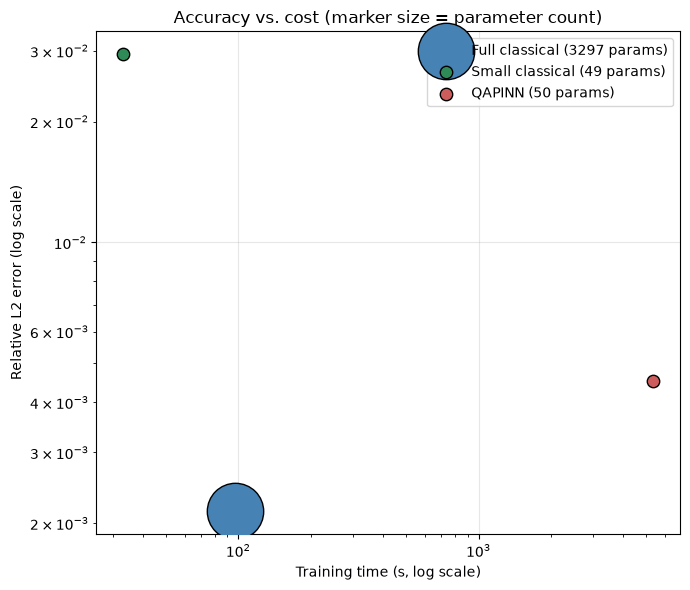

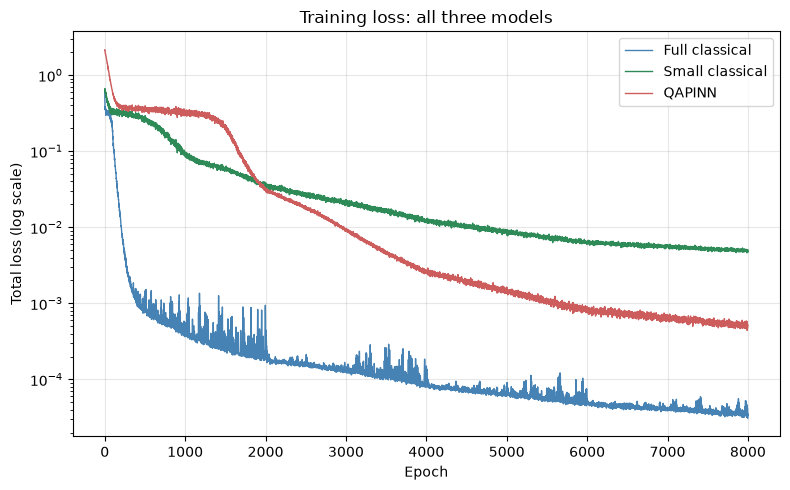

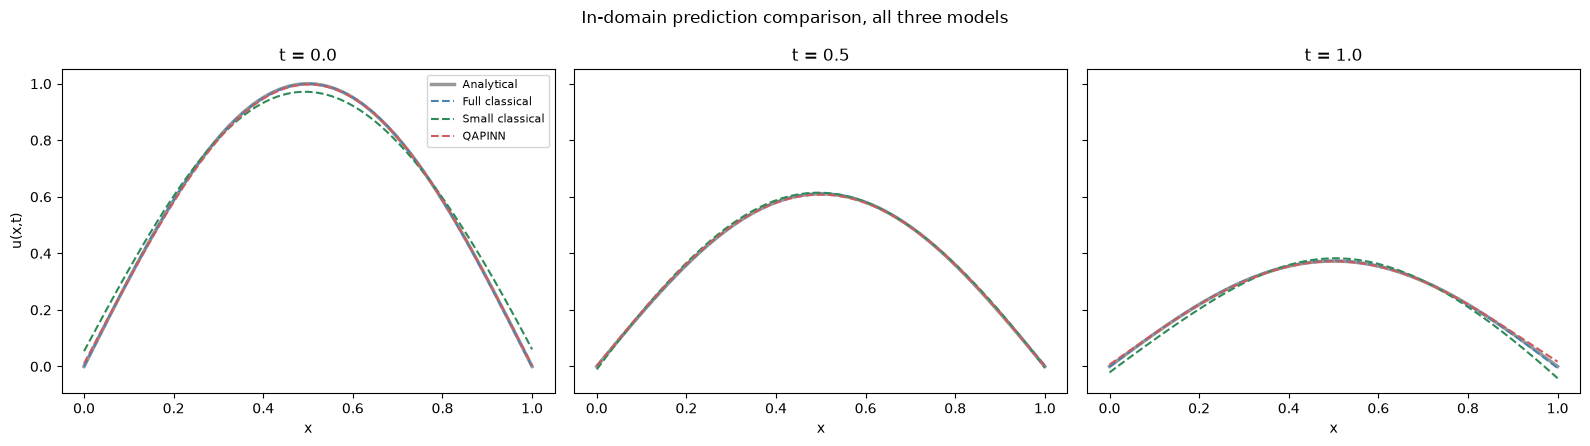

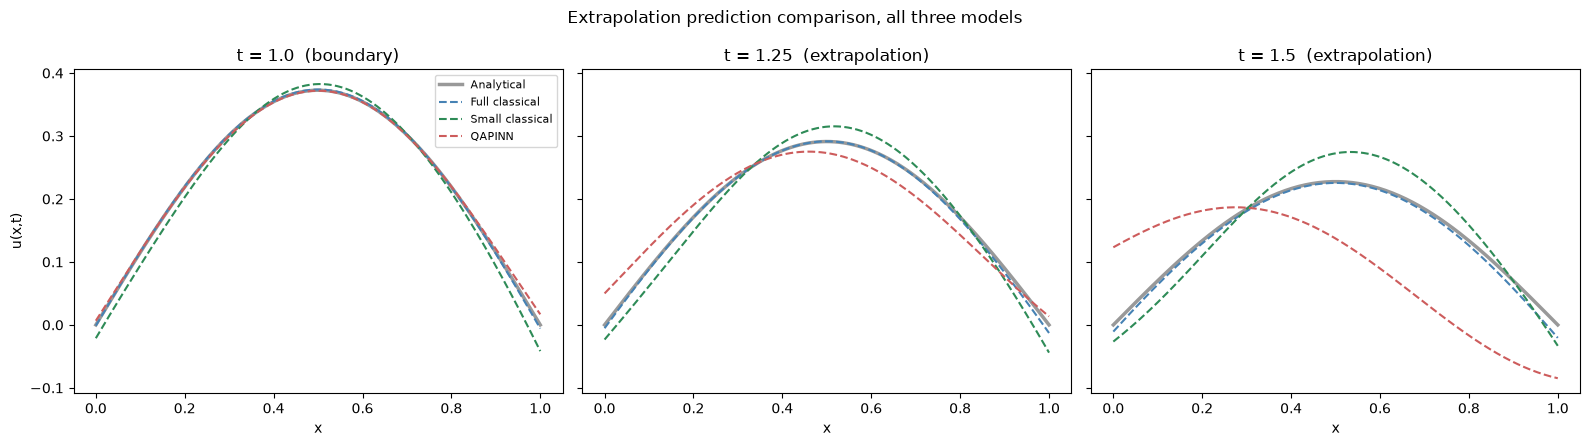


Saved: comparison_bars.png, comparison_efficiency_frontier.png, comparison_loss_curves.png, comparison_slices_indomain.png, comparison_slices_extrapolation.png


In [5]:
 
assert "result_full" in dir(), "result_full not found -- run the full classical PINN script, then `result_full = result`"
assert "result_small" in dir(), "result_small not found -- run the small classical PINN script, then `result_small = result`"
assert "result_qapinn" in dir(), "result_qapinn not found -- run the QAPINN script, then `result_qapinn = result`"
 
MODELS = {
    "Full classical": result_full,
    "Small classical": result_small,
    "QAPINN": result_qapinn,
}
COLORS = {"Full classical": "steelblue", "Small classical": "seagreen", "QAPINN": "indianred"}
NAMES = list(MODELS.keys())
 
 
# ============================================================
# 1. Summary table (printed, no external deps required)
# ============================================================
 
def fmt(v, sig=4):
    if isinstance(v, (int, np.integer)):
        return str(v)
    return f"{v:.{sig}e}" if (abs(v) < 1e-3 or abs(v) >= 1e4) else f"{v:.{sig}f}"
 
rows = [
    ("Trainable parameters", "n_params"),
    ("Relative L2 error (in-domain)", "l2_error"),
    ("PDE residual MSE", "pde_mse"),
    ("PDE residual RMSE", "pde_rmse"),
    ("Extrapolation L2 error", "l2_extrapolation"),
    ("Training time (s)", "training_time"),
    ("Model memory (KB)", "model_mem_kb"),
    ("Peak training memory (MB)", "peak_mem_mb"),
]
 
col_w = 32
print("=" * (col_w + 18 * len(NAMES)))
print(f"{'Metric':<{col_w}}" + "".join(f"{n:>18}" for n in NAMES))
print("-" * (col_w + 18 * len(NAMES)))
for label, key in rows:
    vals = [fmt(MODELS[n][key]) for n in NAMES]
    print(f"{label:<{col_w}}" + "".join(f"{v:>18}" for v in vals))
print("=" * (col_w + 18 * len(NAMES)))
 
# Derived efficiency metrics 
print("\nDerived metrics:")
for n in NAMES:
    r = MODELS[n]
    acc_per_param = 1.0 / (r["l2_error"] * r["n_params"])
    acc_per_second = 1.0 / (r["l2_error"] * r["training_time"])
    print(f"  {n:<18} accuracy-per-param (1/(L2*params)): {acc_per_param:.3e}   "
          f"accuracy-per-second (1/(L2*time)): {acc_per_second:.3e}")
 
 
# ============================================================
# 2. Bar chart panel: accuracy, residual, extrapolation, cost
# ============================================================
 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
 
def bar(ax, key, title, ylabel, logscale=True):
    vals = [MODELS[n][key] for n in NAMES]
    bars = ax.bar(NAMES, vals, color=[COLORS[n] for n in NAMES])
    if logscale:
        ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt(v, 3),
                 ha="center", va="bottom", fontsize=8)
 
bar(axes[0, 0], "l2_error", "In-domain relative L2 error", "L2 error")
bar(axes[0, 1], "l2_extrapolation", "Extrapolation relative L2 error (t up to 1.5)", "L2 error")
bar(axes[1, 0], "training_time", "Training time", "seconds")
bar(axes[1, 1], "n_params", "Trainable parameters", "count")
 
plt.tight_layout()
plt.savefig("comparison_bars.png", dpi=150)
plt.show()
 
 
# ============================================================
# 3. Efficiency frontier: accuracy vs. cost, params encoded as size
# ============================================================
 
plt.figure(figsize=(7, 6))
for n in NAMES:
    r = MODELS[n]
    plt.scatter(r["training_time"], r["l2_error"],
                s=max(80, r["n_params"] * 0.5),
                color=COLORS[n], label=f"{n} ({r['n_params']} params)",
                edgecolors="black", zorder=3)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Training time (s, log scale)")
plt.ylabel("Relative L2 error (log scale)")
plt.title("Accuracy vs. cost (marker size = parameter count)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_efficiency_frontier.png", dpi=150)
plt.show()
 
 
# ============================================================
# 4. Overlaid training loss curves (log scale)
# ============================================================
 
plt.figure(figsize=(8, 5))
for n in NAMES:
    plt.semilogy(MODELS[n]["history"]["total"], label=n, color=COLORS[n], linewidth=1)
plt.xlabel("Epoch"); plt.ylabel("Total loss (log scale)")
plt.title("Training loss: all three models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_loss_curves.png", dpi=150)
plt.show()
 
 
# ============================================================
# 5. Overlaid prediction slices at a few fixed times (in-domain)
# ============================================================
 
DEVICE = torch.device("cpu")
 
def predict_slice(model, t_val, x):
    x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    t_t = torch.full_like(x_t, t_val)
    with torch.no_grad():
        u = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
    return u
 
def exact_solution(x, t, alpha=0.1):
    return np.exp(-alpha * np.pi ** 2 * t) * np.sin(np.pi * x)
 
x = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, t_val in zip(axes, (0.0, 0.5, 1.0)):
    u_true = exact_solution(x, t_val)
    ax.plot(x, u_true, color="black", linewidth=2.5, alpha=0.4, label="Analytical")
    for n in NAMES:
        model = MODELS[n]["model"]
        model.to(DEVICE)
        u_pred = predict_slice(model, t_val, x)
        ax.plot(x, u_pred, "--", color=COLORS[n], label=n)
    ax.set_title(f"t = {t_val}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x,t)")
axes[0].legend(fontsize=8)
plt.suptitle("In-domain prediction comparison, all three models")
plt.tight_layout()
plt.savefig("comparison_slices_indomain.png", dpi=150)
plt.show()
 
 
# ============================================================
# 6. Overlaid extrapolation slices (t beyond training range)
# ============================================================
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, t_val in zip(axes, (1.0, 1.25, 1.5)):
    u_true = exact_solution(x, t_val)
    ax.plot(x, u_true, color="black", linewidth=2.5, alpha=0.4, label="Analytical")
    for n in NAMES:
        model = MODELS[n]["model"]
        model.to(DEVICE)
        u_pred = predict_slice(model, t_val, x)
        ax.plot(x, u_pred, "--", color=COLORS[n], label=n)
    ax.set_title(f"t = {t_val}" + ("  (extrapolation)" if t_val > 1.0 else "  (boundary)"))
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x,t)")
axes[0].legend(fontsize=8)
plt.suptitle("Extrapolation prediction comparison, all three models")
plt.tight_layout()
plt.savefig("comparison_slices_extrapolation.png", dpi=150)
plt.show()
 
print("\nSaved: comparison_bars.png, comparison_efficiency_frontier.png, "
      "comparison_loss_curves.png, comparison_slices_indomain.png, "
      "comparison_slices_extrapolation.png")

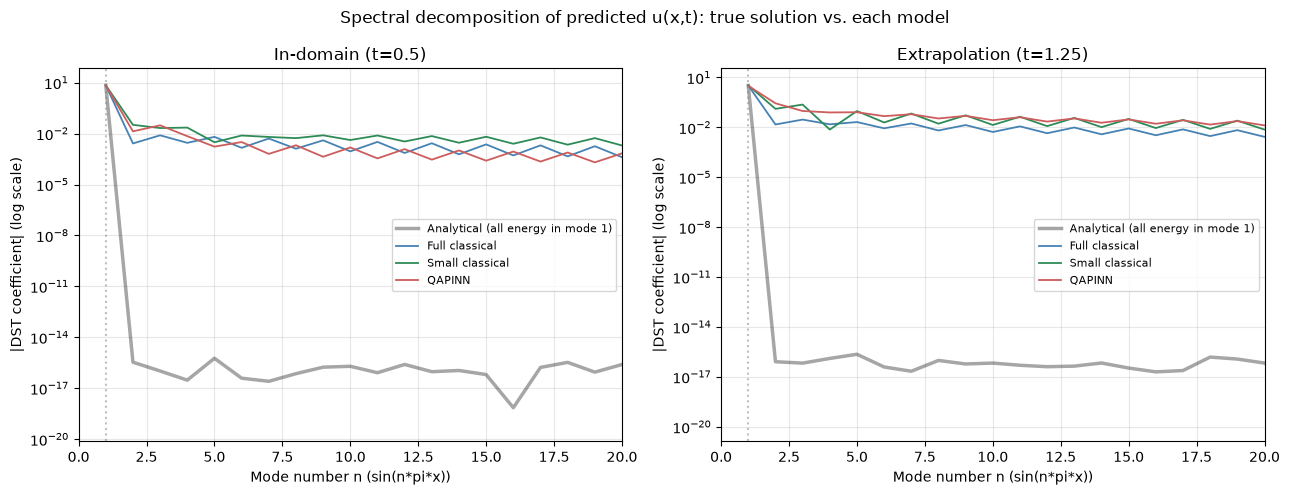

Model                     Leakage (t=0.50)         Leakage (t=1.25)
----------------------------------------------------------------------
Full classical                     0.0004%                  0.0302%
Small classical                    0.0057%                  0.8753%
QAPINN                             0.0025%                  1.2330%

Leakage = fraction of predicted signal's spectral energy OUTSIDE mode 1.
0% = perfectly matches the analytical solution's single-mode structure.
Higher extrapolation leakage than in-domain leakage suggests the model
relies increasingly on spurious harmonics as it moves outside the
training window -- i.e. it is not truly representing exp(-a*pi^2*t)*sin(pi*x),
just approximating it locally with extra frequency content that only
happens to look right inside [0, T_train].


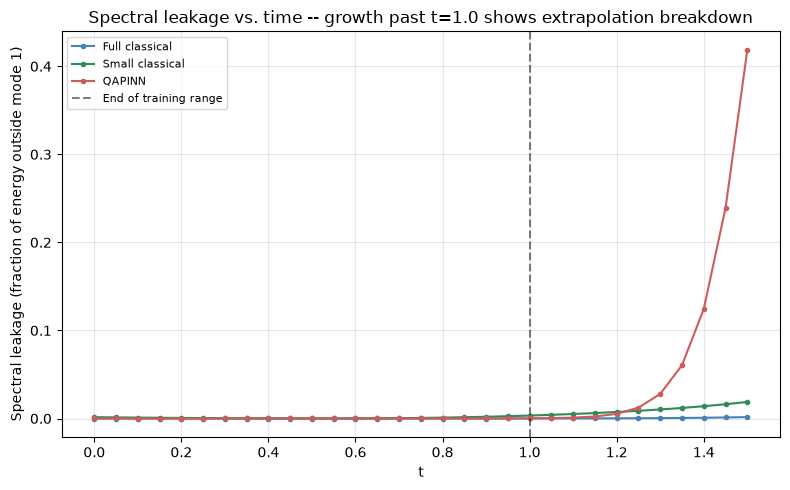


Saved: spectral_comparison.png, spectral_leakage_vs_time.png


In [7]:


import numpy as np
import torch
from scipy.fft import dst
import matplotlib.pyplot as plt

assert "result_full" in dir(), "run result_full = result after the full classical PINN script"
assert "result_small" in dir(), "run result_small = result after the small classical PINN script"
assert "result_qapinn" in dir(), "run result_qapinn = result after the QAPINN script"

MODELS = {
    "Full classical": result_full,
    "Small classical": result_small,
    "QAPINN": result_qapinn,
}
COLORS = {"Full classical": "steelblue", "Small classical": "seagreen", "QAPINN": "indianred"}
NAMES = list(MODELS.keys())

ALPHA = 0.1
DEVICE = torch.device("cpu")


# ============================================================
# DST-I setup
# ============================================================
# DST-I is defined on N *interior* points of [0,1], excluding the
# endpoints (since those are the boundary where u=0 is already
# fixed and not part of the transform). x_i = i/(N+1), i=1..N.

N_MODES = 256

def interior_grid(N=N_MODES):
    i = np.arange(1, N + 1)
    return i / (N + 1)

X_GRID = interior_grid(N_MODES)


def exact_solution(x, t, alpha=ALPHA):
    return np.exp(-alpha * np.pi ** 2 * t) * np.sin(np.pi * x)


def model_slice(model, t_val, x=X_GRID):
    x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    t_t = torch.full_like(x_t, t_val)
    with torch.no_grad():
        u = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
    return u


def spectrum(u):
    """DST-I, orthonormalized so Parseval holds: sum(u^2) == sum(coef^2).
    Returns mode indices (1..N) and |coefficient| per mode."""
    coef = dst(u, type=1, norm="ortho")
    modes = np.arange(1, len(coef) + 1)
    return modes, np.abs(coef)


def spectral_leakage(modes, mag, target_mode=1):
    """Fraction of total spectral energy NOT in the target mode.
    0 = all energy in mode 1 (perfect match to true solution's spectrum).
    Closer to 1 = model has spread energy into spurious modes."""
    energy = mag ** 2
    total = energy.sum()
    leaked = total - energy[modes == target_mode].sum()
    return leaked / total


# ============================================================
# Compare spectra at an in-domain time and an extrapolation time
# ============================================================

T_INDOMAIN = 0.5
T_EXTRAPOLATE = 1.25   # beyond training range [0, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, t_val, title in zip(axes, (T_INDOMAIN, T_EXTRAPOLATE),
                             (f"In-domain (t={T_INDOMAIN})",
                              f"Extrapolation (t={T_EXTRAPOLATE})")):
    u_true = exact_solution(X_GRID, t_val)
    modes_true, mag_true = spectrum(u_true)
    ax.plot(modes_true, mag_true, color="black", linewidth=2.5, alpha=0.35,
             label="Analytical (all energy in mode 1)")

    for n in NAMES:
        model = MODELS[n]["model"]
        model.to(DEVICE)
        u_pred = model_slice(model, t_val)
        modes, mag = spectrum(u_pred)
        ax.plot(modes, mag, color=COLORS[n], label=n, linewidth=1.3)

    ax.set_yscale("log")
    ax.set_xlim(0, 20)   # zoom into the low modes -- that's where the action is
    ax.set_xlabel("Mode number n (sin(n*pi*x))")
    ax.set_ylabel("|DST coefficient| (log scale)")
    ax.set_title(title)
    ax.axvline(1, color="gray", linestyle=":", alpha=0.5)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Spectral decomposition of predicted u(x,t): true solution vs. each model")
plt.tight_layout()
plt.savefig("spectral_comparison.png", dpi=150)
plt.show()


# ============================================================
# Quantitative spectral leakage table
# ============================================================

print("=" * 70)
print(f"{'Model':<20}{'Leakage (t=%.2f)' % T_INDOMAIN:>22}{'Leakage (t=%.2f)' % T_EXTRAPOLATE:>25}")
print("-" * 70)
for n in NAMES:
    model = MODELS[n]["model"]
    model.to(DEVICE)

    u_in = model_slice(model, T_INDOMAIN)
    modes_in, mag_in = spectrum(u_in)
    leak_in = spectral_leakage(modes_in, mag_in)

    u_ex = model_slice(model, T_EXTRAPOLATE)
    modes_ex, mag_ex = spectrum(u_ex)
    leak_ex = spectral_leakage(modes_ex, mag_ex)

    print(f"{n:<20}{leak_in:>22.4%}{leak_ex:>25.4%}")
print("=" * 70)
print("\nLeakage = fraction of predicted signal's spectral energy OUTSIDE mode 1.")
print("0% = perfectly matches the analytical solution's single-mode structure.")
print("Higher extrapolation leakage than in-domain leakage suggests the model")
print("relies increasingly on spurious harmonics as it moves outside the")
print("training window -- i.e. it is not truly representing exp(-a*pi^2*t)*sin(pi*x),")
print("just approximating it locally with extra frequency content that only")
print("happens to look right inside [0, T_train].")


# ============================================================
# how leakage evolves continuously with t
# ============================================================

t_values = np.linspace(0.0, 1.5, 31)

plt.figure(figsize=(8, 5))
for n in NAMES:
    model = MODELS[n]["model"]
    model.to(DEVICE)
    leaks = []
    for t_val in t_values:
        u = model_slice(model, t_val)
        modes, mag = spectrum(u)
        leaks.append(spectral_leakage(modes, mag))
    plt.plot(t_values, leaks, color=COLORS[n], label=n, marker="o", markersize=3)

plt.axvline(1.0, color="black", linestyle="--", alpha=0.5, label="End of training range")
plt.xlabel("t")
plt.ylabel("Spectral leakage (fraction of energy outside mode 1)")
plt.title("Spectral leakage vs. time -- growth past t=1.0 shows extrapolation breakdown")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("spectral_leakage_vs_time.png", dpi=150)
plt.show()

print("\nSaved: spectral_comparison.png, spectral_leakage_vs_time.png")